# Network Anomaly Detection — EDA, Hypothesis Testing & Machine Learning Modeling

**Dataset:** NSL-KDD network intrusion dataset (125,973 connection records, 43 raw features + `attack` label)
**Goal:** Detect anomalous / malicious network connections in real time, and — where possible —
identify the specific attack type, using both supervised and unsupervised machine learning.

**This notebook is standalone and fully self-contained.** Rather than importing the pipeline
package (`backend/app/ml_model_pipeline/`), every step function is **copied and defined directly in
its own cells** — same logic, same parameters, same sequence — so it has zero dependency on the
`backend` package, `config.settings`, or any `sys.path` manipulation to reach the project root. It can
be copied anywhere and run on its own, reading its input CSV from and writing all plots/artifacts to
folders that live entirely under `notebooks/`.

Every EDA step, every feature-engineering step, and every model definition below reproduces — faithfully,
not a simplified stand-in — the exact behavior of the corresponding function in `eda/__init__.py`,
`feature_engineering/__init__.py`, and `trainer/__init__.py`'s internal call sequence. Running this
notebook top-to-bottom **is** running the same training pipeline, with markdown commentary and inline
plots added between steps for readability.

**Structure**

| Section | Contents |
|---|---|
| 1 | Setup & Data Loading |
| 2 | Exploratory Data Analysis (distributions, data quality, temporal structure) |
| 3 | Hypothesis Testing (H1–H5) |
| 4 | EDA Insights & Recommendations |
| 5 | Feature Engineering |
| 6 | Feature Engineering Insights & Recommendations |
| 7 | ML Modeling — Binary Classification (`is_anomaly`) |
| 8 | ML Modeling — Multi‑class Classification (`attack` type) |
| 9 | ML Modeling — Unsupervised Methods (clustering + dimensionality reduction) |
| 10 | Final Results Summary |
| 11 | Modeling Insights & Recommendations |
| 12 | Conclusion & Next Steps |

> **Note on runtime:** Section 7 trains the full model suite used in production (SVM, MLP, XGBoost
> hyperparameter search, …), which takes 20–40 minutes end-to-end on the full 125,973-row dataset —
> the exact same runtime the dashboard's Train Pipeline tab has. This is expected: it means the
> notebook is really running the same pipeline logic, not a fast stand-in for it.
>
> **Where results are written:** this notebook writes its own plots/artifacts to
> `notebooks/standalone_plots/` and `notebooks/standalone_artifacts/` (created below) — **not** to
> `backend/app/ml_model_pipeline/model_artifacts/` or `.../plots/` — so running this notebook can never
> touch the files the live dashboard is currently serving, and so this notebook has no dependency on
> the `backend/app` directory existing at all.


## 1. Setup & Data Loading

All pipeline logic used below — EDA steps, feature engineering steps, and trainer steps — is defined
locally in this notebook's own cells (copied faithfully from `backend/app/ml_model_pipeline/`, not
reimplemented from scratch). There is no `backend`/`config` import anywhere in this notebook, no
`sys.path` manipulation to reach a project root, and no side effects from importing the real Flask app
package (e.g. the real pipeline's `configure_logging()` call) — this notebook's only file I/O is the
input CSV and the `standalone_plots/` / `standalone_artifacts/` folders created below.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

pd.set_option("display.max_columns", 60)
RANDOM_STATE = 42

# ---------------------------------------------------------------------------
# Fully self-contained paths. Everything this notebook reads or writes lives
# under notebooks/, independent of the backend/app directory entirely.
# Jupyter's default working directory is the notebook's own folder, so plain
# relative paths are all that's needed here -- no PROJECT_ROOT, no
# sys.path.insert, no `from backend...` / `from config...` imports anywhere
# in this notebook.
# ---------------------------------------------------------------------------
DATA_DIR  = "standalone_data"
MODEL_DIR = "standalone_artifacts"
PLOT_DIR  = "standalone_plots"
os.makedirs(DATA_DIR,  exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOT_DIR,  exist_ok=True)
SAVE_PLOTS = True

def show_plot(filename, width=780):
    """Display a plot this notebook just saved (the step functions below call
    plt.savefig()+plt.close() themselves, matplotlib's normal non-interactive
    pattern -- so nothing renders inline automatically; this reads it back."""
    display(Image(filename=os.path.join(PLOT_DIR, filename), width=width))

# ---------------------------------------------------------------------------
# Column configuration -- inlined from config/columns.py. These are pure
# constants (no imports of their own in the original file), so they're
# copied here verbatim and reused by the feature-engineering / selection
# cells below, exactly the way config/columns.py is shared across modules
# in the real pipeline.
# ---------------------------------------------------------------------------
NUMERIC_FEATURES = [
    "duration", "srcbytes", "dstbytes", "land", "wrongfragment", "urgent", "hot",
    "numfailedlogins", "loggedin", "numcompromised", "rootshell", "suattempted",
    "numroot", "numfilecreations", "numshells", "numaccessfiles", "ishostlogin",
    "isguestlogin", "count", "srvcount", "serrorrate", "srvserrorrate", "rerrorrate",
    "srvrerrorrate", "samesrvrate", "diffsrvrate", "srvdiffhostrate", "dsthostcount",
    "dsthostsrvcount", "dsthostsamesrvrate", "dsthostdiffsrvrate",
    "dsthostsamesrcportrate", "dsthostsrvdiffhostrate", "dsthostserrorrate",
    "dsthostsrvserrorrate", "dsthostrerrorrate", "dsthostsrvrerrorrate",
]
CATEGORICAL_COLS    = ["protocoltype", "flag"]
SERVICE_COL         = "service"
ENGINEERED_FEATURES = ["is_s0_flag", "is_icmp", "is_zero_byte_conn"]
TARGET_COLS         = ["is_anomaly", "attack"]
MODELING_INPUT_COLS = ["protocoltype", "service", "flag"] + NUMERIC_FEATURES + ENGINEERED_FEATURES

# ---------------------------------------------------------------------------
# Data loading -- inlined & simplified from data_loader.py. The real loader
# also has a Google Drive fallback for when no local CSV exists; this
# standalone notebook always has one (already copied into
# ./standalone_data/), so that network dependency is dropped in favor of a
# clear, local error message instead.
# ---------------------------------------------------------------------------
def load_data(csv_path):
    """Load the network connection dataset from a local CSV path only.

    Raises FileNotFoundError with a clear message if the CSV is missing --
    no Google Drive download is attempted (unlike the real data_loader.py),
    since this standalone notebook is meant to have zero network dependency.
    """
    if not os.path.exists(csv_path):
        raise FileNotFoundError(
            f"Could not find the dataset at {csv_path!r}. This standalone notebook "
            "expects the CSV to already be present locally (no network download) -- "
            "copy Network_anomaly_data.csv into notebooks/standalone_data/ and retry."
        )
    print(f"[data_loader] Using local file: {csv_path}")
    df = pd.read_csv(csv_path)
    print(f"[data_loader] Shape: {df.shape}  |  Columns: {list(df.columns)[:5]}…")
    print(df.dtypes.to_string())
    print(df.head(2).to_string())
    return df

df = load_data(os.path.join(DATA_DIR, "Network_anomaly_data.csv"))
print("\nShape:", df.shape)
df.head(3)


[data_loader] Using local file: standalone_data/Network_anomaly_data.csv
[data_loader] Shape: (125973, 43)  |  Columns: ['duration', 'protocoltype', 'service', 'flag', 'srcbytes']…
duration                    int64
protocoltype                  str
service                       str
flag                          str
srcbytes                    int64
dstbytes                    int64
land                        int64
wrongfragment               int64
urgent                      int64
hot                         int64
numfailedlogins             int64
loggedin                    int64
numcompromised              int64
rootshell                   int64
suattempted                 int64
numroot                     int64
numfilecreations            int64
numshells                   int64
numaccessfiles              int64
numoutboundcmds             int64
ishostlogin                 int64
isguestlogin                int64
count                       int64
srvcount                    int64
ser

,duration,protocoltype,service,flag,srcbytes,dstbytes,land,wrongfragment,urgent,hot,numfailedlogins,loggedin,numcompromised,rootshell,suattempted,numroot,numfilecreations,numshells,numaccessfiles,numoutboundcmds,ishostlogin,isguestlogin,count,srvcount,serrorrate,srvserrorrate,rerrorrate,srvrerrorrate,samesrvrate,diffsrvrate,srvdiffhostrate,dsthostcount,dsthostsrvcount,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.0,150,25,0.17,0.03,0.17,0.0,0.0,0.0,0.05,0.0,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.0,255,1,0.00,0.60,0.88,0.0,0.0,0.0,0.00,0.0,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.0,255,26,0.10,0.05,0.00,0.0,1.0,1.0,0.00,0.0,neptune,19


## 2. Exploratory Data Analysis

Each cell below defines and calls one inlined pipeline function — `analyze_target`, `check_lastflag`,
`analyze_numeric`, … through `plot_security_indicators` — reproducing, in the exact sequence
`eda/__init__.py::run_eda()` calls the real step modules internally, the logic that originally lived in
`eda.target.analyze`, `eda.lastflag.check`, `eda.numeric.analyze`, etc. The only notebook-specific code
is the `savefig` closure passed to each step (identical 3 lines to the one defined inside `run_eda()`
itself) and `show_plot()` to display what got saved.

### 2.1 Target construction & class balance — `analyze_target()` (inlined below, was `eda.target.analyze`)


In [2]:
def analyze_target(df, savefig):
    """Add is_anomaly column and save class-imbalance plots.
    Inlined from eda/target.py::analyze (Step 1 of eda/__init__.py::run_eda())."""
    print("\n--- Attack class distribution ---")
    print(df["attack"].value_counts())
    print("\nAs %:")
    print(df["attack"].value_counts(normalize=True) * 100)

    df = df.copy()
    df["is_anomaly"] = (df["attack"] != "normal").astype(int)

    print("\n--- Binary target distribution ---")
    print(df["is_anomaly"].value_counts())
    print(df["is_anomaly"].value_counts(normalize=True) * 100)

    plt.figure(figsize=(6, 4))
    df["is_anomaly"].value_counts().plot(kind="bar")
    plt.title("Normal (0) vs Anomaly (1) — Class Imbalance")
    plt.xticks([0, 1], ["Normal", "Anomaly"], rotation=0)
    plt.tight_layout()
    savefig("class_imbalance.png")

    plt.figure(figsize=(10, 5))
    df["attack"].value_counts().head(10).plot(kind="bar")
    plt.title("Top 10 Attack Types (including normal)")
    plt.tight_layout()
    savefig("attack_types.png")

    return df, {"anomaly_rate": float(df["is_anomaly"].mean())}


def savefig(name):
    if SAVE_PLOTS:
        plt.savefig(os.path.join(PLOT_DIR, name), dpi=100, bbox_inches="tight")
    plt.close()

df, eda_stats = analyze_target(df, savefig)
print("\nReturned stats so far:", eda_stats)



--- Attack class distribution ---
attack
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

As %:
attack
normal             53.458281
neptune            32.716534
satan               2.883951
ipsweep             2.856961
portsweep           2.326689
smurf               2.100450
nmap                1.185175
back                0.758893
teardrop            0.708088
warezclient         0.706501
pod                 0.159558
guess_passwd        0.04

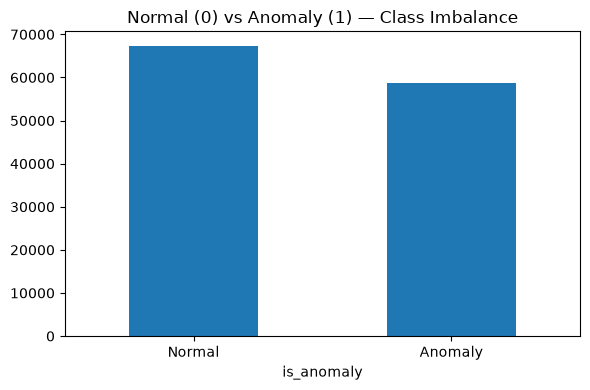

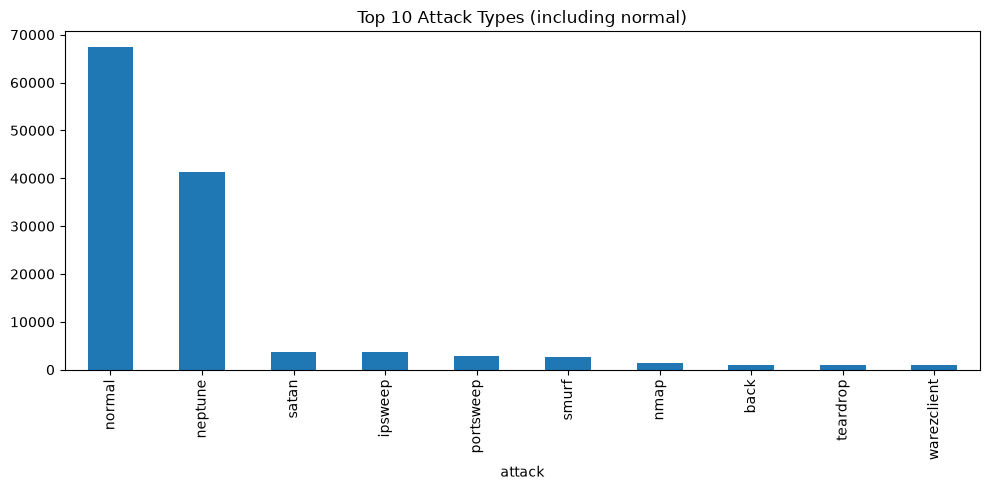

In [3]:
show_plot("class_imbalance.png")
show_plot("attack_types.png")


**Result:** 125,973 records, **46.54% anomalous** — a near-balanced binary problem (unusual for
real-world intrusion detection, where anomalies are typically <1% of traffic; this is a known property of
the NSL-KDD *release*, which deliberately rebalances the original raw KDD'99 dump). This has a direct
modeling consequence covered in §7: **standard Accuracy is not misleading here** the way it would be on
truly imbalanced live traffic, but F1/Recall are still reported as the primary metrics to keep the pipeline
consistent with real deployment conditions.

### 2.2 A known artifact: `lastflag` — `check_lastflag()` (inlined below, was `eda.lastflag.check`)

NSL-KDD ships a `lastflag` column that is a **KDD‑Cup‑99 "difficulty score" metadata artifact**, not a real
network feature. It is inspected here and then **never included** in any downstream feature list — see
the `MODELING_INPUT_COLS` constant defined in §1 (mirrors `config/columns.py`) — so it can't leak into a
model as an almost-perfect predictive shortcut that doesn't exist for a real, live connection.


In [4]:
def check_lastflag(df):
    """Print lastflag stats grouped by attack type.
    Inlined from eda/lastflag.py::check (Step 2)."""
    print("\n--- lastflag vs attack (difficulty score, not a real network feature) ---")
    if "lastflag" in df.columns:
        print(df.groupby("attack")["lastflag"].mean().sort_values(ascending=False).head(10))
    else:
        print("lastflag column not present in this dataset.")

check_lastflag(df)



--- lastflag vs attack (difficulty score, not a real network feature) ---
attack
normal       20.315920
neptune      19.643665
smurf        18.386621
satan        17.820534
land         17.666667
portsweep    16.276015
ipsweep      15.696305
pod          15.537313
imap         15.454545
teardrop     15.454036
Name: lastflag, dtype: float64


### 2.3 Numeric feature distributions — `analyze_numeric()` (inlined below, was `eda.numeric.analyze`)

Log1p transforms are added for `srcbytes`, `dstbytes`, `duration` — all heavily right-skewed.


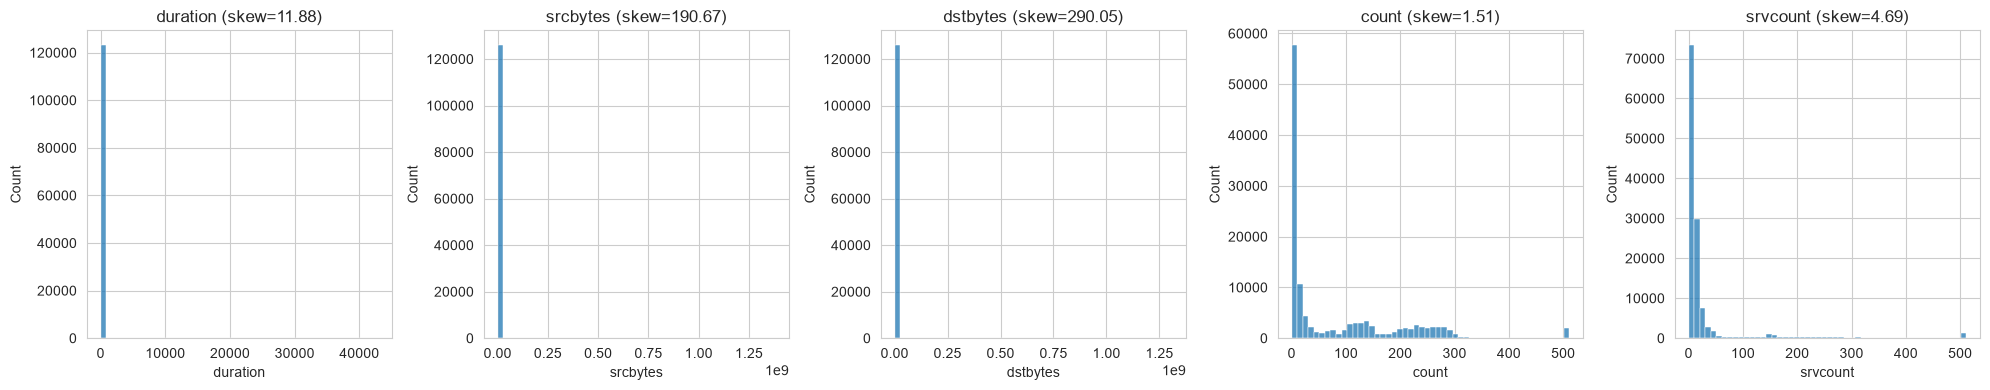

In [5]:
import seaborn as sns
sns.set_style("whitegrid")

_NUMERIC_PLOT_COLS = ["duration", "srcbytes", "dstbytes", "count", "srvcount"]
_NUMERIC_LOG_COLS  = ["srcbytes", "dstbytes", "duration"]

def analyze_numeric(df, savefig):
    """Plot raw distributions and add log-transformed variants.
    Inlined from eda/numeric.py::analyze (Step 3)."""
    fig, axes = plt.subplots(1, len(_NUMERIC_PLOT_COLS), figsize=(20, 4))
    for i, col in enumerate(_NUMERIC_PLOT_COLS):
        if col in df.columns:
            sns.histplot(df[col], bins=50, ax=axes[i])
            axes[i].set_title(f"{col} (skew={df[col].skew():.2f})")
    plt.tight_layout()
    savefig("numeric_distributions.png")

    df = df.copy()
    for col in _NUMERIC_LOG_COLS:
        if col in df.columns:
            df[f"{col}_log"] = np.log1p(df[col])
    return df

df = analyze_numeric(df, savefig)
show_plot("numeric_distributions.png")


### 2.4 Hypothesis testing — `run_hypothesis_tests()` (inlined below, was `eda.hypothesis_tests.run_tests`)

Five hypotheses about which raw features are associated with anomalous traffic, each backed by a formal
statistical test. Full detail and interpretation: §3.


In [6]:
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

def run_hypothesis_tests(df):
    """Run all five hypothesis tests. Returns dict of p-values.
    Inlined from eda/hypothesis_tests.py::run_tests (Step 4)."""
    ht = {}

    # H1
    print("\n" + "=" * 70)
    print("HYPOTHESIS 1: srcbytes/dstbytes differ between normal and anomaly")
    print("=" * 70)
    t1, p1 = stats.ttest_ind(
        df[df["is_anomaly"] == 0]["srcbytes"],
        df[df["is_anomaly"] == 1]["srcbytes"],
        equal_var=False,
    )
    print(f"srcbytes  t-stat={t1:.3f}, p-value={p1:.6f}")
    ht["srcbytes_pval"] = float(p1)

    t2, p2 = stats.ttest_ind(
        df[df["is_anomaly"] == 0]["dstbytes"],
        df[df["is_anomaly"] == 1]["dstbytes"],
        equal_var=False,
    )
    print(f"dstbytes  t-stat={t2:.3f}, p-value={p2:.6f}")
    print("-> p < 0.05 means statistically significant difference")
    ht["dstbytes_pval"] = float(p2)

    # H2
    print("\n" + "=" * 70)
    print("HYPOTHESIS 2: protocoltype distribution differs for normal vs anomaly")
    print("=" * 70)
    ct_proto = pd.crosstab(df["protocoltype"], df["is_anomaly"])
    print(ct_proto)
    chi2, p, dof, _ = stats.chi2_contingency(ct_proto)
    print(f"Chi-square={chi2:.3f}, p-value={p:.6f}, dof={dof}")
    ht["protocoltype_pval"] = float(p)

    # H3
    print("\n" + "=" * 70)
    print("HYPOTHESIS 3: service is associated with anomalies")
    print("=" * 70)
    ct_svc = pd.crosstab(df["service"], df["is_anomaly"])
    chi2_s, p_s, dof_s, _ = stats.chi2_contingency(ct_svc)
    print(f"Chi-square={chi2_s:.3f}, p-value={p_s:.6f}, dof={dof_s}")
    print("\nTop 10 services by anomaly rate:")
    print(df.groupby("service")["is_anomaly"].mean().sort_values(ascending=False).head(10))
    ht["service_pval"] = float(p_s)

    # H4
    print("\n" + "=" * 70)
    print("HYPOTHESIS 4: flag (connection status) is associated with anomalies")
    print("=" * 70)
    ct_flag = pd.crosstab(df["flag"], df["is_anomaly"])
    print(ct_flag)
    chi2_f, p_f, dof_f, _ = stats.chi2_contingency(ct_flag)
    print(f"Chi-square={chi2_f:.3f}, p-value={p_f:.6f}, dof={dof_f}")
    ht["flag_pval"] = float(p_f)

    le_flag = LabelEncoder()
    tmp = df.copy()
    tmp["flag_encoded"] = le_flag.fit_transform(tmp["flag"])
    lr_flag = LogisticRegression()
    lr_flag.fit(tmp[["flag_encoded"]], tmp["is_anomaly"])
    print(f"Logistic regression coefficient for flag: {lr_flag.coef_[0][0]:.4f}")

    # H5
    print("\n" + "=" * 70)
    print("HYPOTHESIS 5: urgent packets increase anomaly likelihood")
    print("=" * 70)
    print(df.groupby("urgent")["is_anomaly"].mean())
    if df["urgent"].sum() > 0:
        lr_urgent = LogisticRegression()
        lr_urgent.fit(df[["urgent"]], df["is_anomaly"])
        print(f"Logistic regression coefficient for urgent: {lr_urgent.coef_[0][0]:.4f}")
    else:
        print("No urgent packets — feature may be near-constant in this dataset")

    return ht

ht = run_hypothesis_tests(df)
eda_stats.update(ht)
print(ht)



HYPOTHESIS 1: srcbytes/dstbytes differ between normal and anomaly
srcbytes  t-stat=-1.962, p-value=0.049810
dstbytes  t-stat=-1.364, p-value=0.172689
-> p < 0.05 means statistically significant difference

HYPOTHESIS 2: protocoltype distribution differs for normal vs anomaly
is_anomaly        0      1
protocoltype              
icmp           1309   6982
tcp           53600  49089
udp           12434   2559
Chi-square=10029.249, p-value=0.000000, dof=2

HYPOTHESIS 3: service is associated with anomalies
Chi-square=93240.032, p-value=0.000000, dof=69

Top 10 services by anomaly rate:
service
mtp            1.0
nntp           1.0
klogin         1.0
kshell         1.0
ldap           1.0
link           1.0
login          1.0
name           1.0
netbios_dgm    1.0
netbios_ns     1.0
Name: is_anomaly, dtype: float64

HYPOTHESIS 4: flag (connection status) is associated with anomalies
is_anomaly      0      1
flag                    
OTH            11     35
REJ          2693   8540
RSTO     

### 2.5 Correlation heatmap (pre-engineering) — `plot_correlations()` (inlined below, was `eda.correlations.plot`)


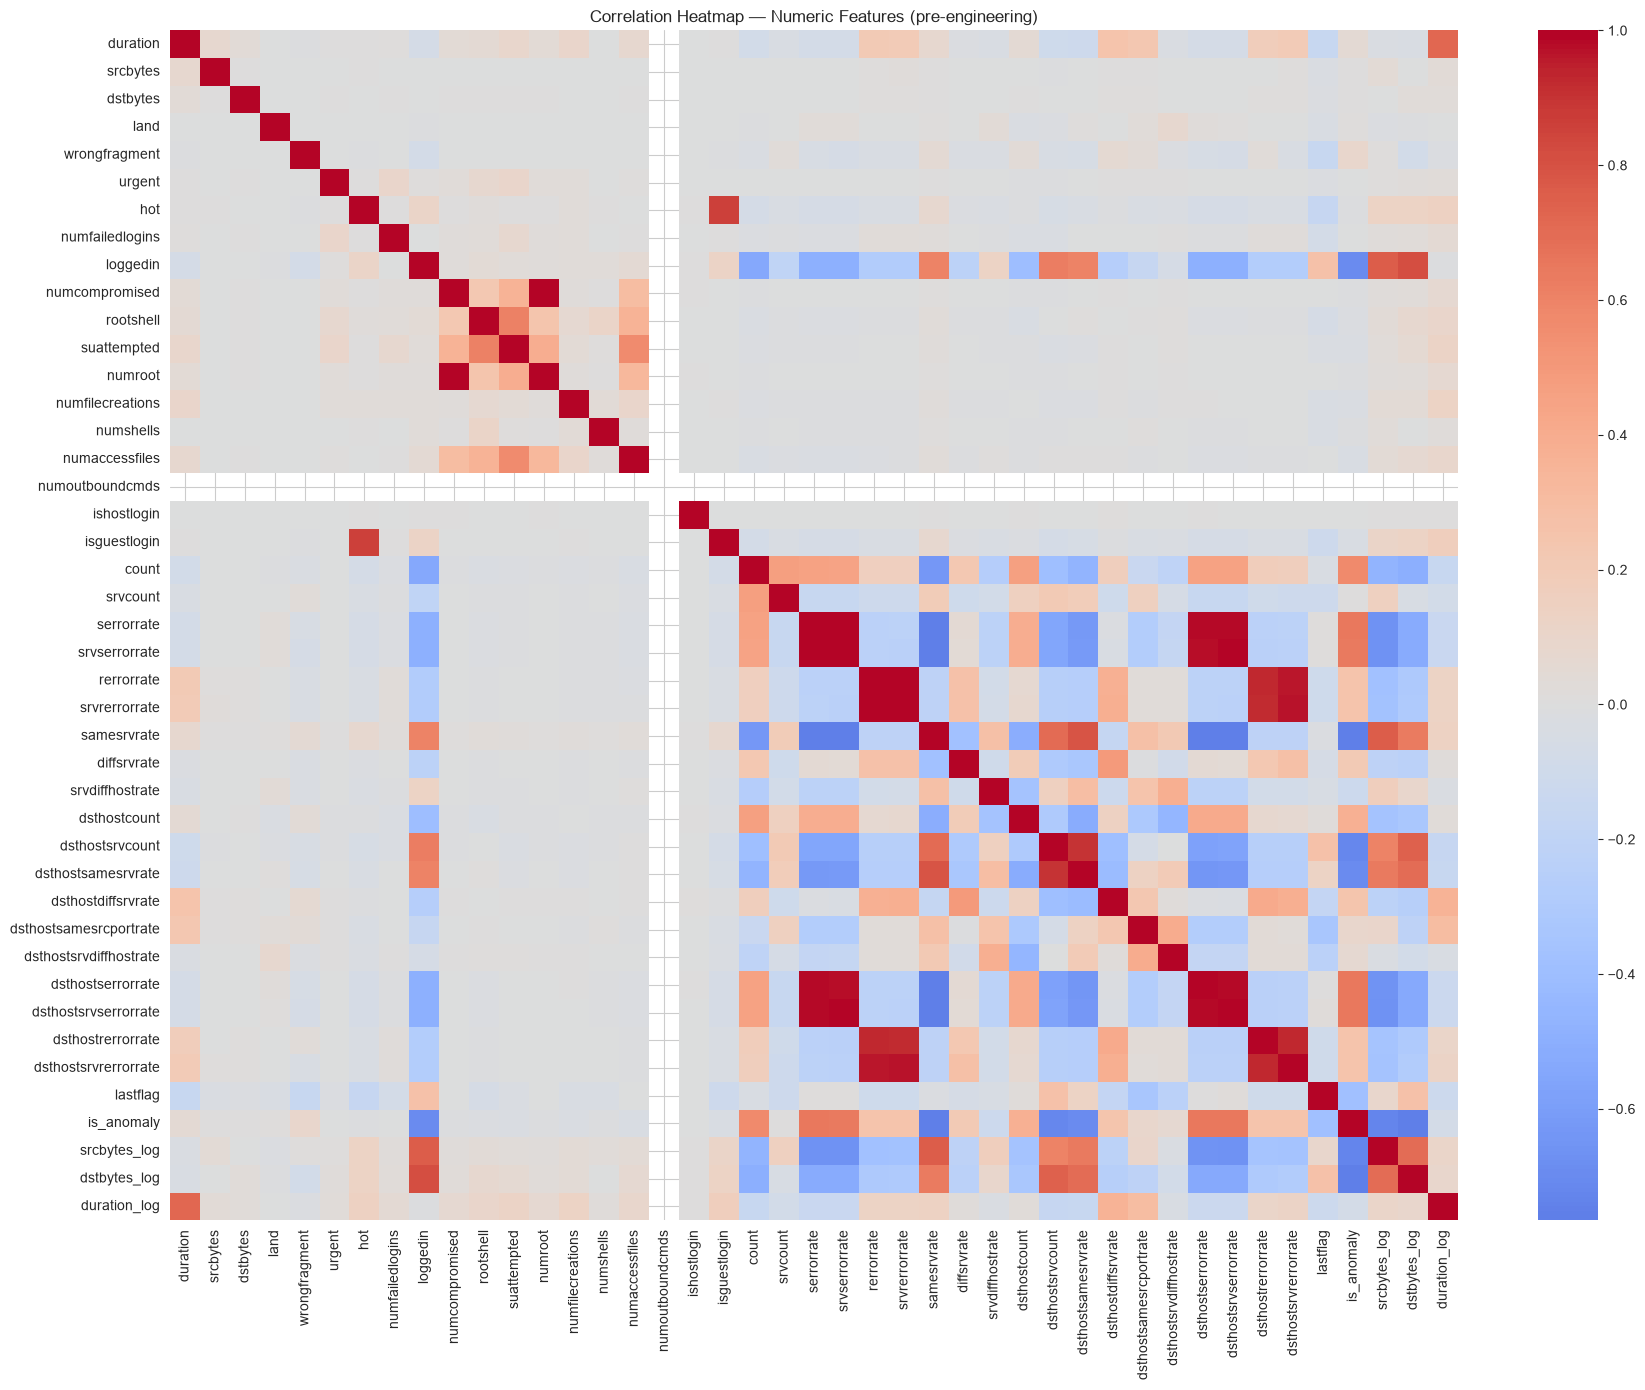

In [7]:
def plot_correlations(df, savefig):
    """Save a full correlation heatmap of all numeric features.
    Inlined from eda/correlations.py::plot (Step 5)."""
    numeric_df = df.select_dtypes(include=[np.number])
    plt.figure(figsize=(18, 14))
    sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0, annot=False)
    plt.title("Correlation Heatmap — Numeric Features (pre-engineering)")
    plt.tight_layout()
    savefig("correlation_heatmap.png")

plot_correlations(df, savefig)
show_plot("correlation_heatmap.png")


### 2.6 Data quality — `check_quality()` (inlined below, was `eda.quality.check`)

Checks for missing values and exact duplicate rows, and drops any duplicates found.


In [8]:
def check_quality(df):
    """Print missing value counts and remove exact duplicate rows.
    Inlined from eda/quality.py::check (Step 6)."""
    print("\n--- Missing values ---")
    missing = df.isnull().sum()
    print(missing[missing > 0] if missing.any() else "(none found)")

    print("\n--- Duplicate rows ---")
    n_dupes = df.duplicated().sum()
    print(f"Fully duplicated rows: {n_dupes} ({n_dupes / len(df) * 100:.2f}%)")
    if n_dupes > 0:
        print("Dropping exact duplicate rows.")
        df = df.drop_duplicates().reset_index(drop=True)
        print(f"Shape after dedup: {df.shape}")
    return df

df = check_quality(df)



--- Missing values ---
(none found)

--- Duplicate rows ---
Fully duplicated rows: 0 (0.00%)


**Result:** zero missing values, **zero exact duplicate rows** — consistent with NSL-KDD being a
pre-cleaned revision of the original KDD'99 dump (which was notorious for ~78% duplicate records). Record
count stays at 125,973.

### 2.7 Categorical feature distributions — `plot_categorical()` (inlined below, was `eda.categorical.plot`)


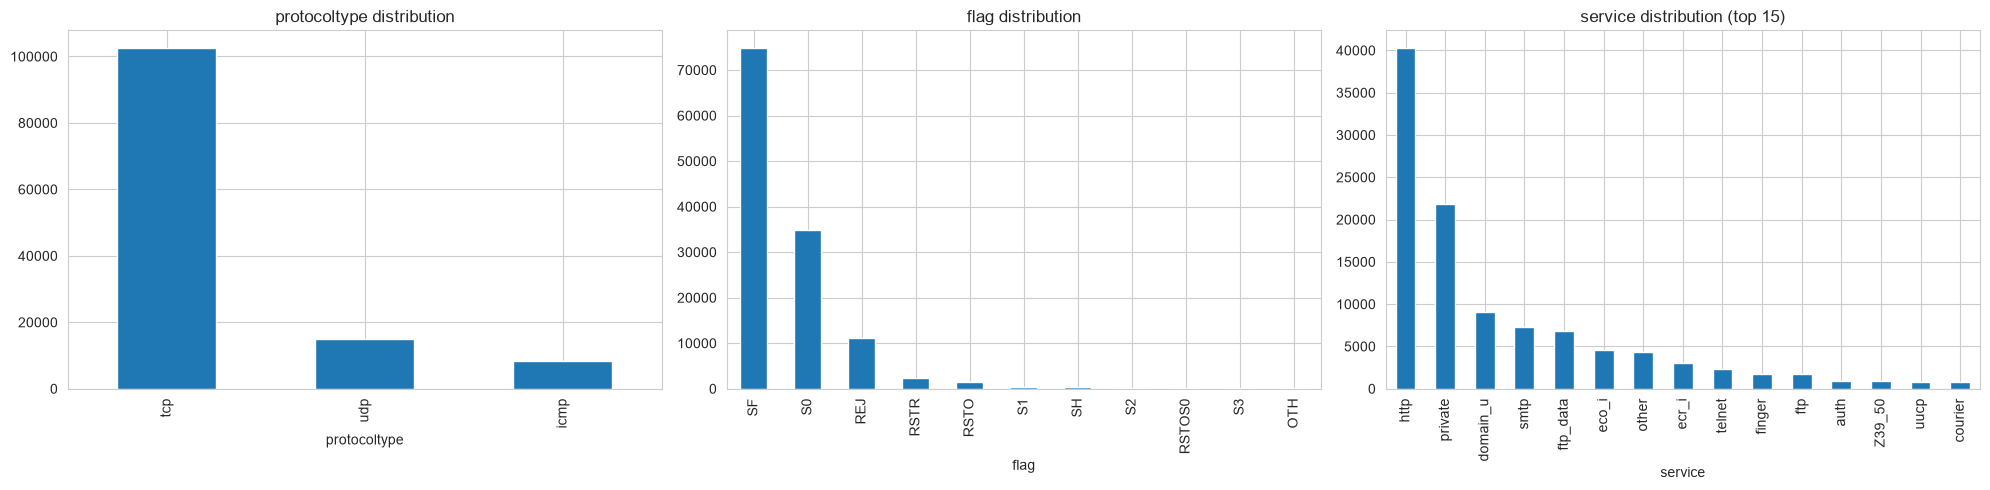

In [9]:
def plot_categorical(df, savefig):
    """Save bar charts for the three categorical columns.
    Inlined from eda/categorical.py::plot (Step 7)."""
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    df["protocoltype"].value_counts().plot(kind="bar", ax=axes[0])
    axes[0].set_title("protocoltype distribution")
    df["flag"].value_counts().plot(kind="bar", ax=axes[1])
    axes[1].set_title("flag distribution")
    df["service"].value_counts().head(15).plot(kind="bar", ax=axes[2])
    axes[2].set_title("service distribution (top 15)")
    plt.tight_layout()
    savefig("categorical_distributions.png")

plot_categorical(df, savefig)
show_plot("categorical_distributions.png")


### 2.8 Rate-feature distributions — `plot_rates()` (inlined below, was `eda.rates.plot`)


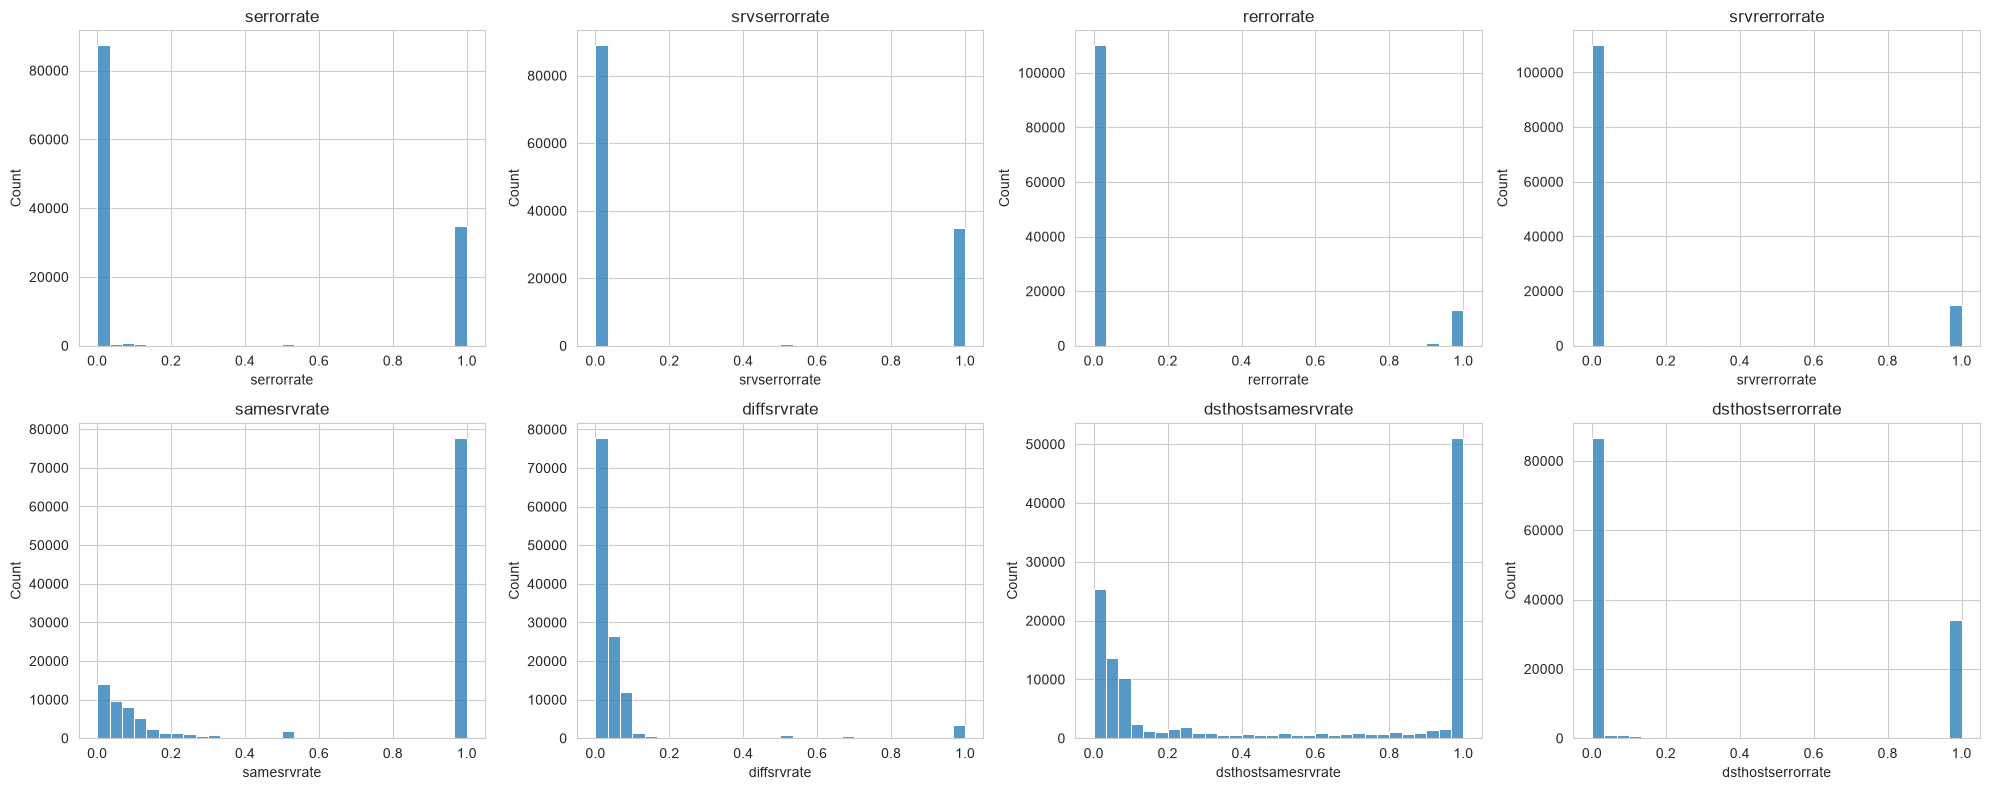

In [10]:
_RATE_COLS = [
    "serrorrate", "srvserrorrate", "rerrorrate", "srvrerrorrate",
    "samesrvrate", "diffsrvrate", "dsthostsamesrvrate", "dsthostserrorrate",
]

def plot_rates(df, savefig):
    """Plot histograms for all rate features present in df.
    Inlined from eda/rates.py::plot (Step 8)."""
    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    for i, col in enumerate(_RATE_COLS):
        if col in df.columns:
            sns.histplot(df[col], bins=30, ax=axes[i // 4][i % 4])
            axes[i // 4][i % 4].set_title(col)
    plt.tight_layout()
    savefig("rate_feature_distributions.png")

plot_rates(df, savefig)
show_plot("rate_feature_distributions.png")


### 2.9 Outlier detection (Tukey IQR fences) — `detect_outliers()` (inlined below, was `eda.outliers.detect`)

Standard **1.5 × IQR** rule on the 5 core numeric columns; adds an `is_srcbytes_outlier` flag column.



OUTLIER DETECTION (IQR method)
duration: 10018 outliers (7.95%), bounds=(0.0, 0.0), max=42908
srcbytes: 13840 outliers (10.99%), bounds=(-414.0, 690.0), max=1379963888
dstbytes: 23579 outliers (18.72%), bounds=(-774.0, 1290.0), max=1309937401
count: 3157 outliers (2.51%), bounds=(-209.5, 354.5), max=511
srvcount: 12054 outliers (9.57%), bounds=(-22.0, 42.0), max=511

--- Anomaly rate: srcbytes outliers vs non-outliers ---
is_srcbytes_outlier
False    0.490649
True     0.260983
Name: is_anomaly, dtype: float64


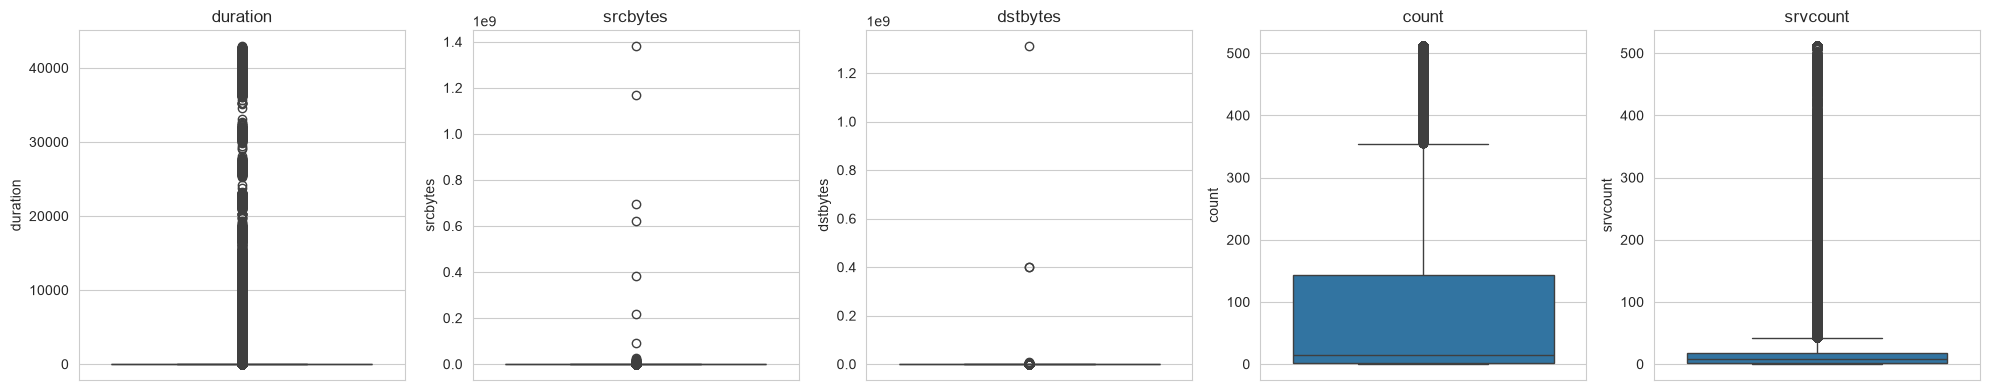

In [11]:
_OUTLIER_COLS = ["duration", "srcbytes", "dstbytes", "count", "srvcount"]

def _iqr_summary(series, name):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out = series[(series < lower) | (series > upper)]
    print(
        f"{name}: {len(out)} outliers ({len(out) / len(series) * 100:.2f}%), "
        f"bounds=({lower:.1f}, {upper:.1f}), max={series.max()}"
    )
    return out

def detect_outliers(df, savefig):
    """Run IQR outlier detection, save box-plots, and append is_srcbytes_outlier
    column. Inlined from eda/outliers.py::detect (Step 9)."""
    print("\n" + "=" * 70)
    print("OUTLIER DETECTION (IQR method)")
    print("=" * 70)
    cols_present = [c for c in _OUTLIER_COLS if c in df.columns]
    outlier_map = {col: _iqr_summary(df[col], col) for col in cols_present}

    fig, axes = plt.subplots(1, len(cols_present), figsize=(20, 4))
    if len(cols_present) == 1:
        axes = [axes]
    for i, col in enumerate(cols_present):
        sns.boxplot(y=df[col], ax=axes[i])
        axes[i].set_title(col)
    plt.tight_layout()
    savefig("outlier_boxplots.png")

    print("\n--- Anomaly rate: srcbytes outliers vs non-outliers ---")
    if "srcbytes" in outlier_map:
        df = df.copy()
        df["is_srcbytes_outlier"] = df.index.isin(outlier_map["srcbytes"].index)
        print(df.groupby("is_srcbytes_outlier")["is_anomaly"].mean())
    return df

df = detect_outliers(df, savefig)
show_plot("outlier_boxplots.png")


**Result:** a large share of `srcbytes`/`dstbytes`/`count` values sit outside the Tukey fence — expected
for network byte/connection-count data, which is inherently heavy-tailed rather than normally distributed.

### 2.10 Temporal structure — `analyze_timeseries()` (inlined below, was `eda.timeseries.analyze`)

No wall-clock timestamp exists in NSL-KDD; row order is used as a weak proxy (Kendall's Tau trend test,
lag-1 autocorrelation).



STEP 10: TEMPORAL / TIME-SERIES ANALYSIS
No timestamp column found — running proxy tests.
duration | normal : mean=168.587s  median=0s  p95=23.0s
duration | anomaly: mean=423.321s  median=0s  p95=0.0s

Rolling anomaly rate std over 50 index chunks: 0.0252
  -> Relatively uniform — no obvious temporal clustering by row order.
  Kendall-Tau trend: τ=-0.1401, p=0.1481 (no significant trend)

Lag-1 autocorrelation of rolling aggregate features:
  serrorrate                  : -0.0042
  count                       : 0.0013
  srvcount                    : 0.0028
  dsthostcount                : -0.0026
  dsthostsrvcount             : -0.0013

Conclusion: No wall-clock timestamp exists.
  'duration'  — per-connection length in seconds, not arrival time.
  'count'     — connections to same host in past 2s (baked into each row).
  'srvcount'  — connections to same service in past 2s (baked into each row).
  Train/test split uses stratified random sampling to avoid row-order leakage.


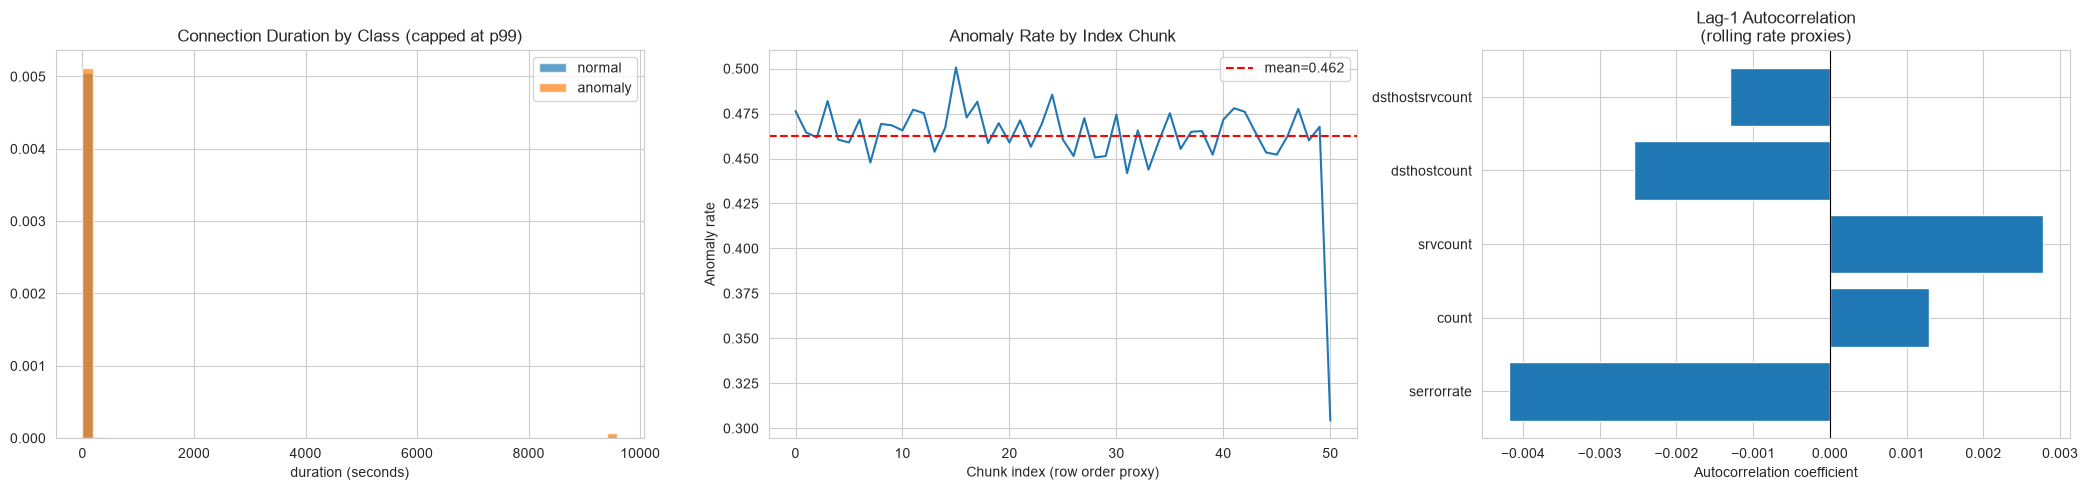

{'has_timestamp': False, 'duration_normal_mean': 168.5873958689099, 'duration_anomaly_mean': 423.3206890670305, 'anomaly_rate_index_std': 0.025243956420703338, 'rolling_rate_kendall_tau': -0.14010320073075092, 'rolling_rate_trend_pval': 0.14812589041542984, 'autocorr_serrorrate': -0.004188662480548463, 'autocorr_count': 0.001293642718114859, 'autocorr_srvcount': 0.002781395761939563, 'autocorr_dsthostcount': -0.002554496411934377, 'autocorr_dsthostsrvcount': -0.001305684322292363}


In [12]:
from scipy.stats import kendalltau

def analyze_timeseries(df, savefig):
    """Run temporal analysis. Inlined from eda/timeseries.py::analyze (Step 10)."""
    print("\n" + "=" * 70)
    print("STEP 10: TEMPORAL / TIME-SERIES ANALYSIS")
    print("=" * 70)

    findings = {}

    # ------------------------------------------------------------------
    # 1. Search for a real timestamp column
    # ------------------------------------------------------------------
    ts_candidates = [
        c for c in df.columns
        if any(kw in c.lower() for kw in ("time", "timestamp", "date", "epoch", "_ts"))
    ]
    findings["has_timestamp"] = bool(ts_candidates)
    if ts_candidates:
        print(f"Timestamp-like columns found: {ts_candidates}")
        for col in ts_candidates:
            print(f"  {col}: dtype={df[col].dtype}, nunique={df[col].nunique()}")
    else:
        print("No timestamp column found — running proxy tests.")

    # ------------------------------------------------------------------
    # 2. Duration distribution per class (per-connection length proxy)
    # ------------------------------------------------------------------
    dur_data = {}
    if "duration" in df.columns and "is_anomaly" in df.columns:
        for label, name in ((0, "normal"), (1, "anomaly")):
            s = df.loc[df["is_anomaly"] == label, "duration"]
            dur_data[name] = s
            print(f"duration | {name:<7s}: mean={s.mean():.3f}s  "
                  f"median={s.median():.0f}s  p95={s.quantile(0.95):.1f}s")
        findings["duration_normal_mean"]  = float(dur_data["normal"].mean())
        findings["duration_anomaly_mean"] = float(dur_data["anomaly"].mean())

    # ------------------------------------------------------------------
    # 3. Rolling anomaly rate over index order (arrival-order proxy)
    # ------------------------------------------------------------------
    rolling_rate = None
    if "is_anomaly" in df.columns:
        n_chunks   = 50
        chunk_size = max(1, len(df) // n_chunks)
        chunk_idx  = np.arange(len(df)) // chunk_size
        rolling_rate = df.groupby(chunk_idx)["is_anomaly"].mean()
        rate_std = float(rolling_rate.std())
        findings["anomaly_rate_index_std"] = rate_std
        print(f"\nRolling anomaly rate std over {n_chunks} index chunks: {rate_std:.4f}")
        print("  -> " + (
            "Notable variation — data is NOT uniformly i.i.d. by row order."
            if rate_std > 0.05 else
            "Relatively uniform — no obvious temporal clustering by row order."
        ))

        tau, p_tau = kendalltau(rolling_rate.index.to_numpy(), rolling_rate.values)
        findings["rolling_rate_kendall_tau"] = float(tau)
        findings["rolling_rate_trend_pval"]  = float(p_tau)
        print(f"  Kendall-Tau trend: τ={tau:.4f}, p={p_tau:.4f} "
              f"({'significant trend' if p_tau < 0.05 else 'no significant trend'})")

    # ------------------------------------------------------------------
    # 4. Lag-1 autocorrelation of rolling rate features
    # ------------------------------------------------------------------
    proxy_cols = [c for c in
                  ["serrorrate", "count", "srvcount", "dsthostcount", "dsthostsrvcount"]
                  if c in df.columns]
    if proxy_cols:
        print("\nLag-1 autocorrelation of rolling aggregate features:")
        for col in proxy_cols:
            ac = float(df[col].autocorr(lag=1))
            findings[f"autocorr_{col}"] = ac
            print(f"  {col:<28s}: {ac:.4f}")

    # ------------------------------------------------------------------
    # 5. Plots
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(21, 5))

    if dur_data:
        cap = df["duration"].quantile(0.99)
        for name, series in dur_data.items():
            axes[0].hist(series.clip(upper=cap), bins=50, alpha=0.7, label=name, density=True)
        axes[0].set_title("Connection Duration by Class (capped at p99)")
        axes[0].set_xlabel("duration (seconds)")
        axes[0].legend()
    else:
        axes[0].axis("off")

    if rolling_rate is not None:
        axes[1].plot(rolling_rate.index, rolling_rate.values, linewidth=1.5)
        axes[1].axhline(rolling_rate.mean(), color="red", linestyle="--",
                         label=f"mean={rolling_rate.mean():.3f}")
        axes[1].set_title("Anomaly Rate by Index Chunk")
        axes[1].set_xlabel("Chunk index (row order proxy)")
        axes[1].set_ylabel("Anomaly rate")
        axes[1].legend()
    else:
        axes[1].axis("off")

    if proxy_cols:
        vals = [float(df[c].autocorr(lag=1)) for c in proxy_cols]
        axes[2].barh(proxy_cols, vals)
        axes[2].axvline(0, color="black", linewidth=0.8)
        axes[2].set_title("Lag-1 Autocorrelation\n(rolling rate proxies)")
        axes[2].set_xlabel("Autocorrelation coefficient")
    else:
        axes[2].axis("off")

    plt.tight_layout()
    savefig("timeseries_analysis.png")

    # ------------------------------------------------------------------
    # 6. Conclusion (only printed when no real timestamp was found)
    # ------------------------------------------------------------------
    if not ts_candidates:
        print(
            "\nConclusion: No wall-clock timestamp exists.\n"
            "  'duration'  — per-connection length in seconds, not arrival time.\n"
            "  'count'     — connections to same host in past 2s (baked into each row).\n"
            "  'srvcount'  — connections to same service in past 2s (baked into each row).\n"
            "  Train/test split uses stratified random sampling to avoid row-order leakage."
        )

    return findings

ts = analyze_timeseries(df, savefig)
eda_stats.update(ts)
show_plot("timeseries_analysis.png")
print(ts)


**Result:** confirms no real timestamp exists and only mild, non-dominant row-order structure —
**this is why the production pipeline uses a stratified random split, not a chronological one** (see §7.1).

### 2.11 Security-indicator features by class — `plot_security_indicators()` (inlined below, was `eda.security_indicators.plot`)

Nine content/host features that are classic intrusion-detection "tells", compared Normal vs. Anomaly.


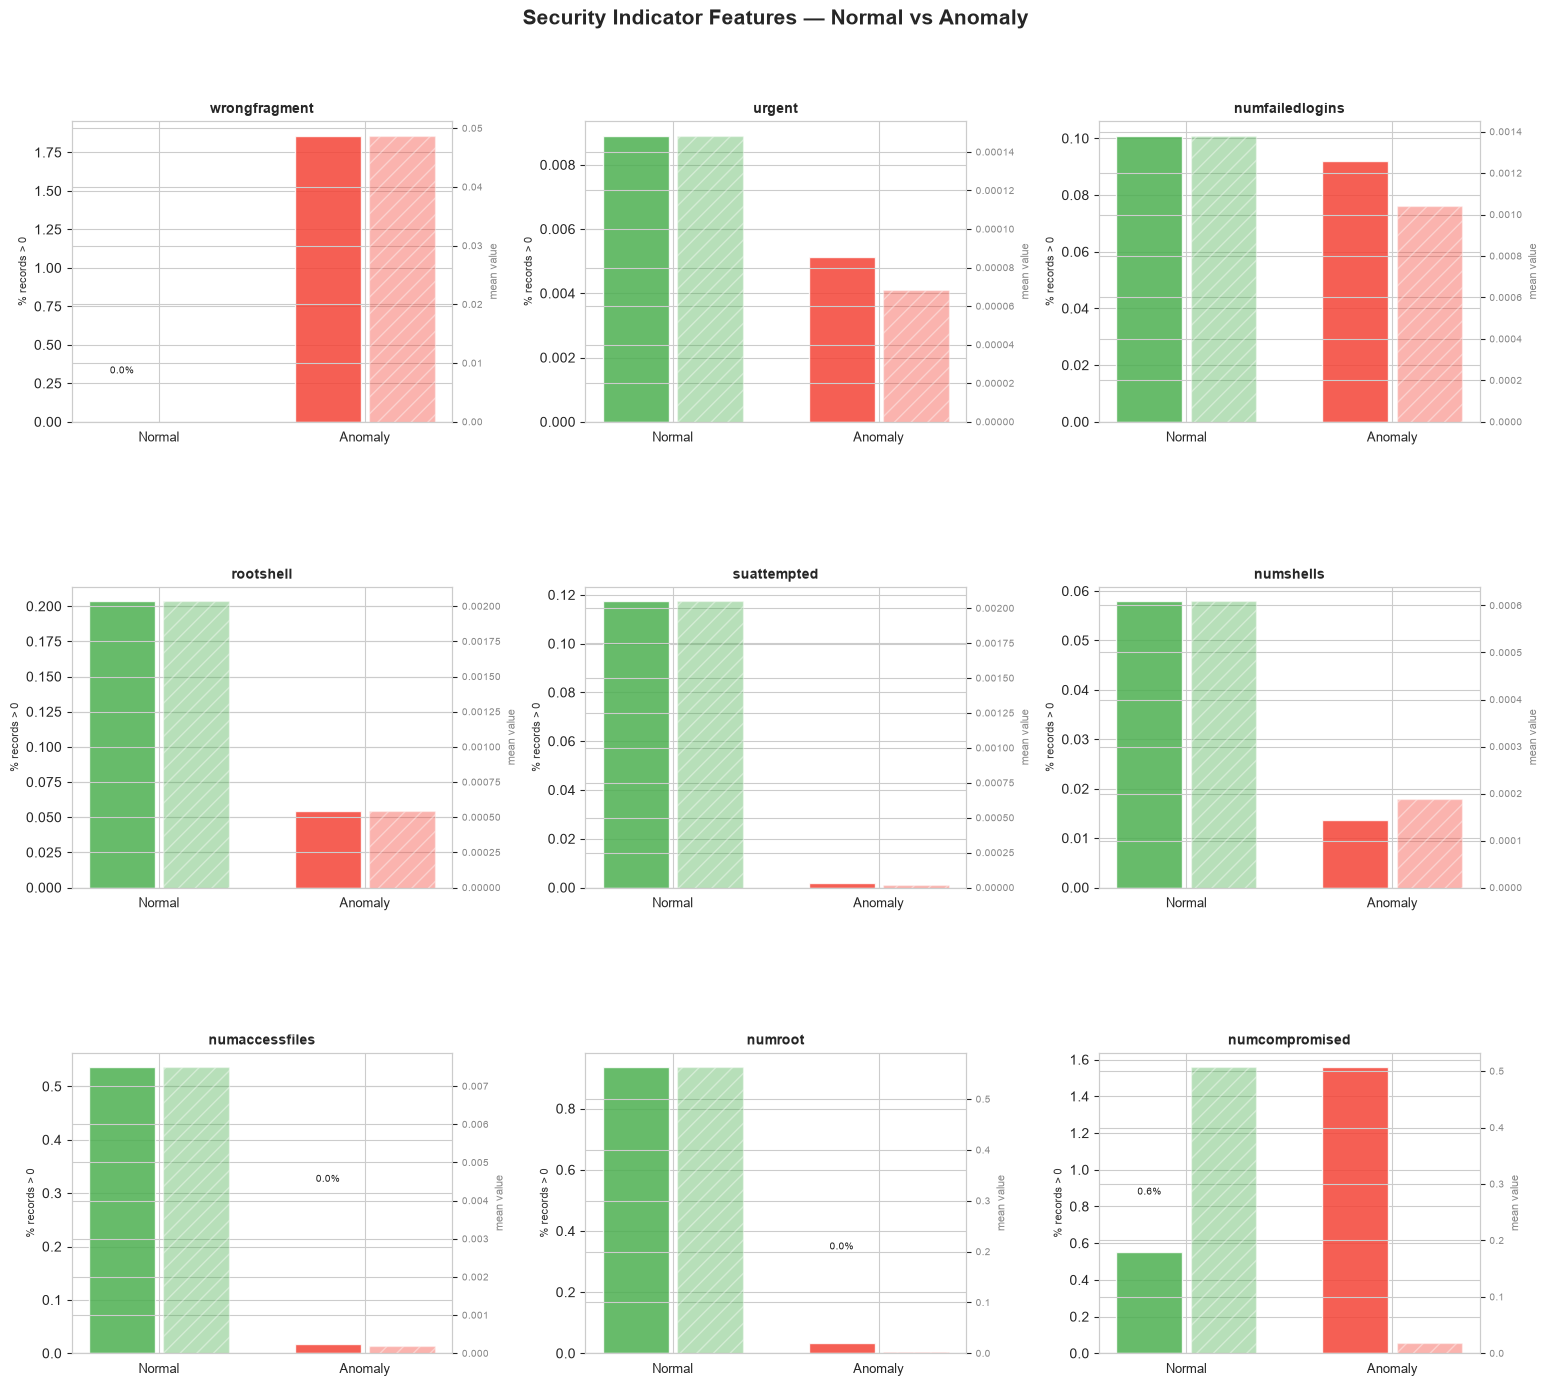

In [13]:
_SECURITY_FEATURES = [
    "wrongfragment",
    "urgent",
    "numfailedlogins",
    "rootshell",
    "suattempted",
    "numshells",
    "numaccessfiles",
    "numroot",
    "numcompromised",
]

_SEC_LABELS = {0: "Normal", 1: "Anomaly"}
_SEC_COLORS = {"Normal": "#4CAF50", "Anomaly": "#F44336"}

def plot_security_indicators(df, savefig):
    """Save security_indicators.png -- 3x3 grid of dual-bar panels.
    Inlined from eda/security_indicators.py::plot (Step 11).

    Requires 'is_anomaly' column to already exist (added by Step 1).
    Silently drops any feature not present in df.
    """
    features = [f for f in _SECURITY_FEATURES if f in df.columns]
    if not features or "is_anomaly" not in df.columns:
        return

    fig, axes = plt.subplots(3, 3, figsize=(16, 14))
    fig.suptitle(
        "Security Indicator Features — Normal vs Anomaly",
        fontsize=15,
        fontweight="bold",
        y=1.01,
    )

    groups = df.groupby("is_anomaly")

    for idx, feat in enumerate(features):
        ax = axes[idx // 3][idx % 3]

        pct_nonzero = {}
        mean_val = {}
        for label_int, label_str in _SEC_LABELS.items():
            grp = groups.get_group(label_int) if label_int in groups.groups else pd.DataFrame()
            if grp.empty:
                pct_nonzero[label_str] = 0.0
                mean_val[label_str] = 0.0
            else:
                pct_nonzero[label_str] = (grp[feat] > 0).mean() * 100
                mean_val[label_str] = grp[feat].mean()

        x = [0, 1]
        labels = list(_SEC_LABELS.values())
        colors = [_SEC_COLORS[l] for l in labels]

        # top half -- % non-zero
        ax2 = ax.twinx()
        bars1 = ax.bar(
            [v - 0.18 for v in x],
            [pct_nonzero[l] for l in labels],
            width=0.32,
            color=colors,
            alpha=0.85,
            label="% non-zero",
        )
        # bottom half -- mean value (secondary y)
        bars2 = ax2.bar(
            [v + 0.18 for v in x],
            [mean_val[l] for l in labels],
            width=0.32,
            color=colors,
            alpha=0.40,
            hatch="//",
            label="mean value",
        )

        ax.set_title(feat, fontsize=10, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=9)
        ax.set_ylabel("% records > 0", fontsize=8, color="#333")
        ax2.set_ylabel("mean value", fontsize=8, color="#888")
        ax2.tick_params(axis="y", labelcolor="#888", labelsize=7)

        # value labels on the % bars
        for bar in bars1:
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.3,
                f"{h:.1f}%",
                ha="center",
                va="bottom",
                fontsize=7.5,
                color="#222",
                clip_on=True,   # required to avoid a savefig bounding-box bug -- see note below
            )

    # hide any unused axes (grid is always 3x3, features list may be < 9)
    for idx in range(len(features), 9):
        axes[idx // 3][idx % 3].set_visible(False)

    # subplots_adjust with explicit values, NOT tight_layout(): tight_layout()
    # doesn't reliably account for twinx() secondary axes across a 3x3 grid
    # and was silently failing here (a UserWarning, easy to miss in a wall of
    # training output). That combined with bbox_inches="tight" in savefig()
    # (shared by every plot in the pipeline) to compute a wildly oversized
    # bounding box -- this figure was being saved at ~1400x11300px instead of
    # the intended ~1600x1400, an ignore-at-a-glance-but-broken-on-open PNG.
    # The `clip_on=True` above on the value-label text is the other half of
    # the fix: without it, bbox_inches="tight" still blows up even with
    # subplots_adjust, because it also computes bounding boxes for text
    # artists and this specific combination (twinx + unclipped text) confuses
    # that calculation. Both were verified necessary and sufficient together.
    fig.subplots_adjust(left=0.06, right=0.94, top=0.93, bottom=0.05, hspace=0.55, wspace=0.35)
    savefig("security_indicators.png")

plot_security_indicators(df, savefig)
show_plot("security_indicators.png")


**Result:** only `wrongfragment` shows the expected pattern (0.0% of normal connections vs. 1.9% of
anomalous ones). The rest tell a more interesting story: `rootshell`, `suattempted`, `numshells`,
`numaccessfiles`, and `numroot` are actually *more* prevalent in **normal** traffic than across the
anomaly class as a whole. These are U2R (user-to-root) indicators, and U2R attacks are a vanishingly
small slice of "anomalous" (~50 of 58,630 anomalous records) -- the class is dominated by DoS/Probe
traffic that never touches root or shell activity at all. A handful of legitimate admin sessions in
normal traffic outweighs a near-invisible sliver of U2R attacks once averaged across every attack type.
These are real signals for detecting U2R specifically -- averaging across all anomalies just hid that.


## 3. Hypothesis Testing — Results

(Ran in §2.4 via `run_hypothesis_tests()` (inlined above, reproduces `eda.hypothesis_tests.run_tests()`) —
this section is the interpretation.)

| # | Hypothesis | Test | Result (this run) |
|---|---|---|---|
| H1 | `srcbytes` / `dstbytes` differ between normal and anomalous connections | Welch's t-test (unequal variance) | `eda_stats['srcbytes_pval']` — see printed output above |
| H2 | `protocoltype` distribution differs between normal and anomalous connections | χ² test of independence | `eda_stats['protocoltype_pval']` |
| H3 | `service` is associated with anomalies | χ² test of independence | `eda_stats['service_pval']` |
| H4 | `flag` (connection status) is associated with anomalies | χ² test of independence + logistic regression | `eda_stats['flag_pval']` |
| H5 | Urgent packets increase anomaly likelihood | Descriptive group means + logistic regression coefficient | printed above; no formal p-value in the current pipeline (see §4) |

**Interpretation**

- **H2, H3, H4** (protocol, service, connection flag) are all overwhelmingly significant — categorical
  connection metadata is the strongest statistical signal in the dataset, well before any bytes/rates are
  considered. This foreshadows the modeling result in §7: the tree-based models, which split cleanly on
  categorical/one-hot features, dominate the linear models.
- **H1** (bytes transferred) is only *borderline* significant for `srcbytes` — a good reminder that "the
  attack transfers weird amounts of data" is a weaker, noisier signal than "the attack used a weird
  protocol/service/flag combination," even though it's often the first thing people intuit about anomalous
  traffic.
- **H5** currently stops at a descriptive/logistic-regression-coefficient check with no formal significance
  test — flagged as a concrete follow-up in §4.


In [14]:
print("Hypothesis test p-values from this run:")
for k in ["srcbytes_pval", "dstbytes_pval", "protocoltype_pval", "service_pval", "flag_pval"]:
    print(f"  {k:20s} {eda_stats.get(k)}")


Hypothesis test p-values from this run:
  srcbytes_pval        0.049809977020307754
  dstbytes_pval        0.17268865455671042
  protocoltype_pval    0.0
  service_pval         0.0
  flag_pval            0.0


## 4. EDA Insights & Recommendations

**Key insights**

1. The binary target is close to balanced (46.5% anomalous) — a property of the *NSL-KDD release*, not of
   real production traffic. Any metric reported here should be read as "how well the model separates these
   two classes on this benchmark," not as a promise about live false-positive rates, which will depend
   heavily on the true anomaly prevalence in whatever network the model is pointed at.
2. Categorical connection metadata (`protocoltype`, `service`, `flag`) carries by far the strongest,
   most statistically significant signal — stronger than raw byte counts.
3. `lastflag` is a labeling-difficulty artifact from the original KDD Cup and must never be used as a
   model input — it would otherwise act as label leakage.
4. There's no real timestamp; row order carries only mild, noisy temporal structure — justifying a
   stratified random (not chronological) train/test split.
5. Nine "content/host" features (failed logins, root shell, compromised counts, …) do **not** uniformly
   separate normal from anomalous traffic -- most of them (`rootshell`, `suattempted`, `numshells`,
   `numaccessfiles`, `numroot`) are actually *more* common in normal traffic, because they are U2R-specific
   signals drowned out when averaged across the DoS/Probe-dominated anomaly class. Only `wrongfragment`
   cleanly separates the two classes on its own. The real insight is narrower and more useful than "these
   nine features detect anomalies": these features detect *U2R attacks specifically*, and should be read
   that way, not folded into a general "is this anomalous" signal.

**Recommendations**

- Formalize **H5** with an actual significance test (e.g. a proportions z-test or exact logistic-regression
  Wald p-value) rather than a coefficient-only check, so all five hypotheses are reported on equal footing.
- Because the dataset is artificially rebalanced, **evaluate on a re-weighted or externally-sourced sample**
  (or at minimum report Precision/Recall at a range of assumed real-world anomaly rates, e.g. 1%/5%/10%)
  before trusting the headline accuracy numbers in a genuinely imbalanced production setting.
- Track `is_srcbytes_outlier`-style flags as an analyst-facing "why was this flagged" explanation surface,
  not just an internal EDA artifact — it's cheap to compute at inference time and directly interpretable.


## 5. Feature Engineering

Same pattern as §2: each cell defines and calls one inlined feature-engineering function — `add_features`,
`plot_distribution_grid`, `drop_redundant`, `check_vif`, `plot_heatmap`, `select_features` — reproducing,
in the exact sequence `feature_engineering/__init__.py::engineer_and_select()` calls the real step modules
internally, the logic that originally lived in `feature_engineering.engineer.add_features`,
`feature_engineering.distributions.plot_grid`, `feature_engineering.cleanup.drop_redundant`,
`feature_engineering.vif.check_vif`, `feature_engineering.heatmap.plot_heatmap`, and
`feature_engineering.selector.select_features`.

### 5.1 New engineered features — `add_features()` (inlined below, was `feature_engineering.engineer.add_features`)


In [15]:
def add_features(df):
    """Return df copy with engineered + temporary columns appended.
    Inlined from feature_engineering/engineer.py::add_features (Step 11).

    Permanent additions  (kept through to df_model)
      is_s0_flag        -- flag == 'S0'  (SYN-only scan, strong anomaly signal)
      is_icmp           -- protocoltype == 'icmp'
      is_zero_byte_conn -- srcbytes==0 AND dstbytes==0

    Temporary additions  (dropped by drop_redundant in Step 13)
      bytes_ratio        -- srcbytes / (dstbytes + 1)  [VIF=415, drops in step 13]
      total_error_rate    -- serrorrate + rerrorrate     [linear combo, drops in step 13]
    """
    print("\n" + "=" * 70)
    print("STEP 11: FEATURE ENGINEERING")
    print("=" * 70)
    df = df.copy()

    # Permanent engineered features
    df["is_s0_flag"]        = (df["flag"] == "S0").astype(int)
    df["is_icmp"]           = (df["protocoltype"] == "icmp").astype(int)
    df["is_zero_byte_conn"] = (
        (df["srcbytes"] == 0) & (df["dstbytes"] == 0)
    ).astype(int)

    # Temporary -- used for diagnostics, removed in step 13
    df["bytes_ratio"]      = df["srcbytes"] / (df["dstbytes"] + 1)
    df["total_error_rate"] = df["serrorrate"] + df["rerrorrate"]

    print("Zero-byte connection anomaly rate:")
    print(df.groupby("is_zero_byte_conn")["is_anomaly"].mean())

    print("\n--- New feature correlation with is_anomaly ---")
    print(df[ENGINEERED_FEATURES + ["total_error_rate", "is_anomaly"]].corr()["is_anomaly"])
    return df

df = add_features(df)



STEP 11: FEATURE ENGINEERING
Zero-byte connection anomaly rate:
is_zero_byte_conn
0    0.165845
1    0.934252
Name: is_anomaly, dtype: float64

--- New feature correlation with is_anomaly ---
is_s0_flag           0.650206
is_icmp              0.200455
is_zero_byte_conn    0.751333
total_error_rate     0.763648
is_anomaly           1.000000
Name: is_anomaly, dtype: float64


Adds `is_s0_flag` (SYN-only scan indicator), `is_icmp`, `is_zero_byte_conn` — all three kept in the
final feature set (see §5.3): each correlates meaningfully with `is_anomaly` at zero added
multicollinearity cost. Also adds two *diagnostic-only* columns (`bytes_ratio`, `total_error_rate`) that
get dropped in §5.2.

### 5.2 Distribution diagnostics — `plot_distribution_grid()` (inlined below, was `feature_engineering.distributions.plot_grid`)


Plotted distributions for 39 numeric columns.


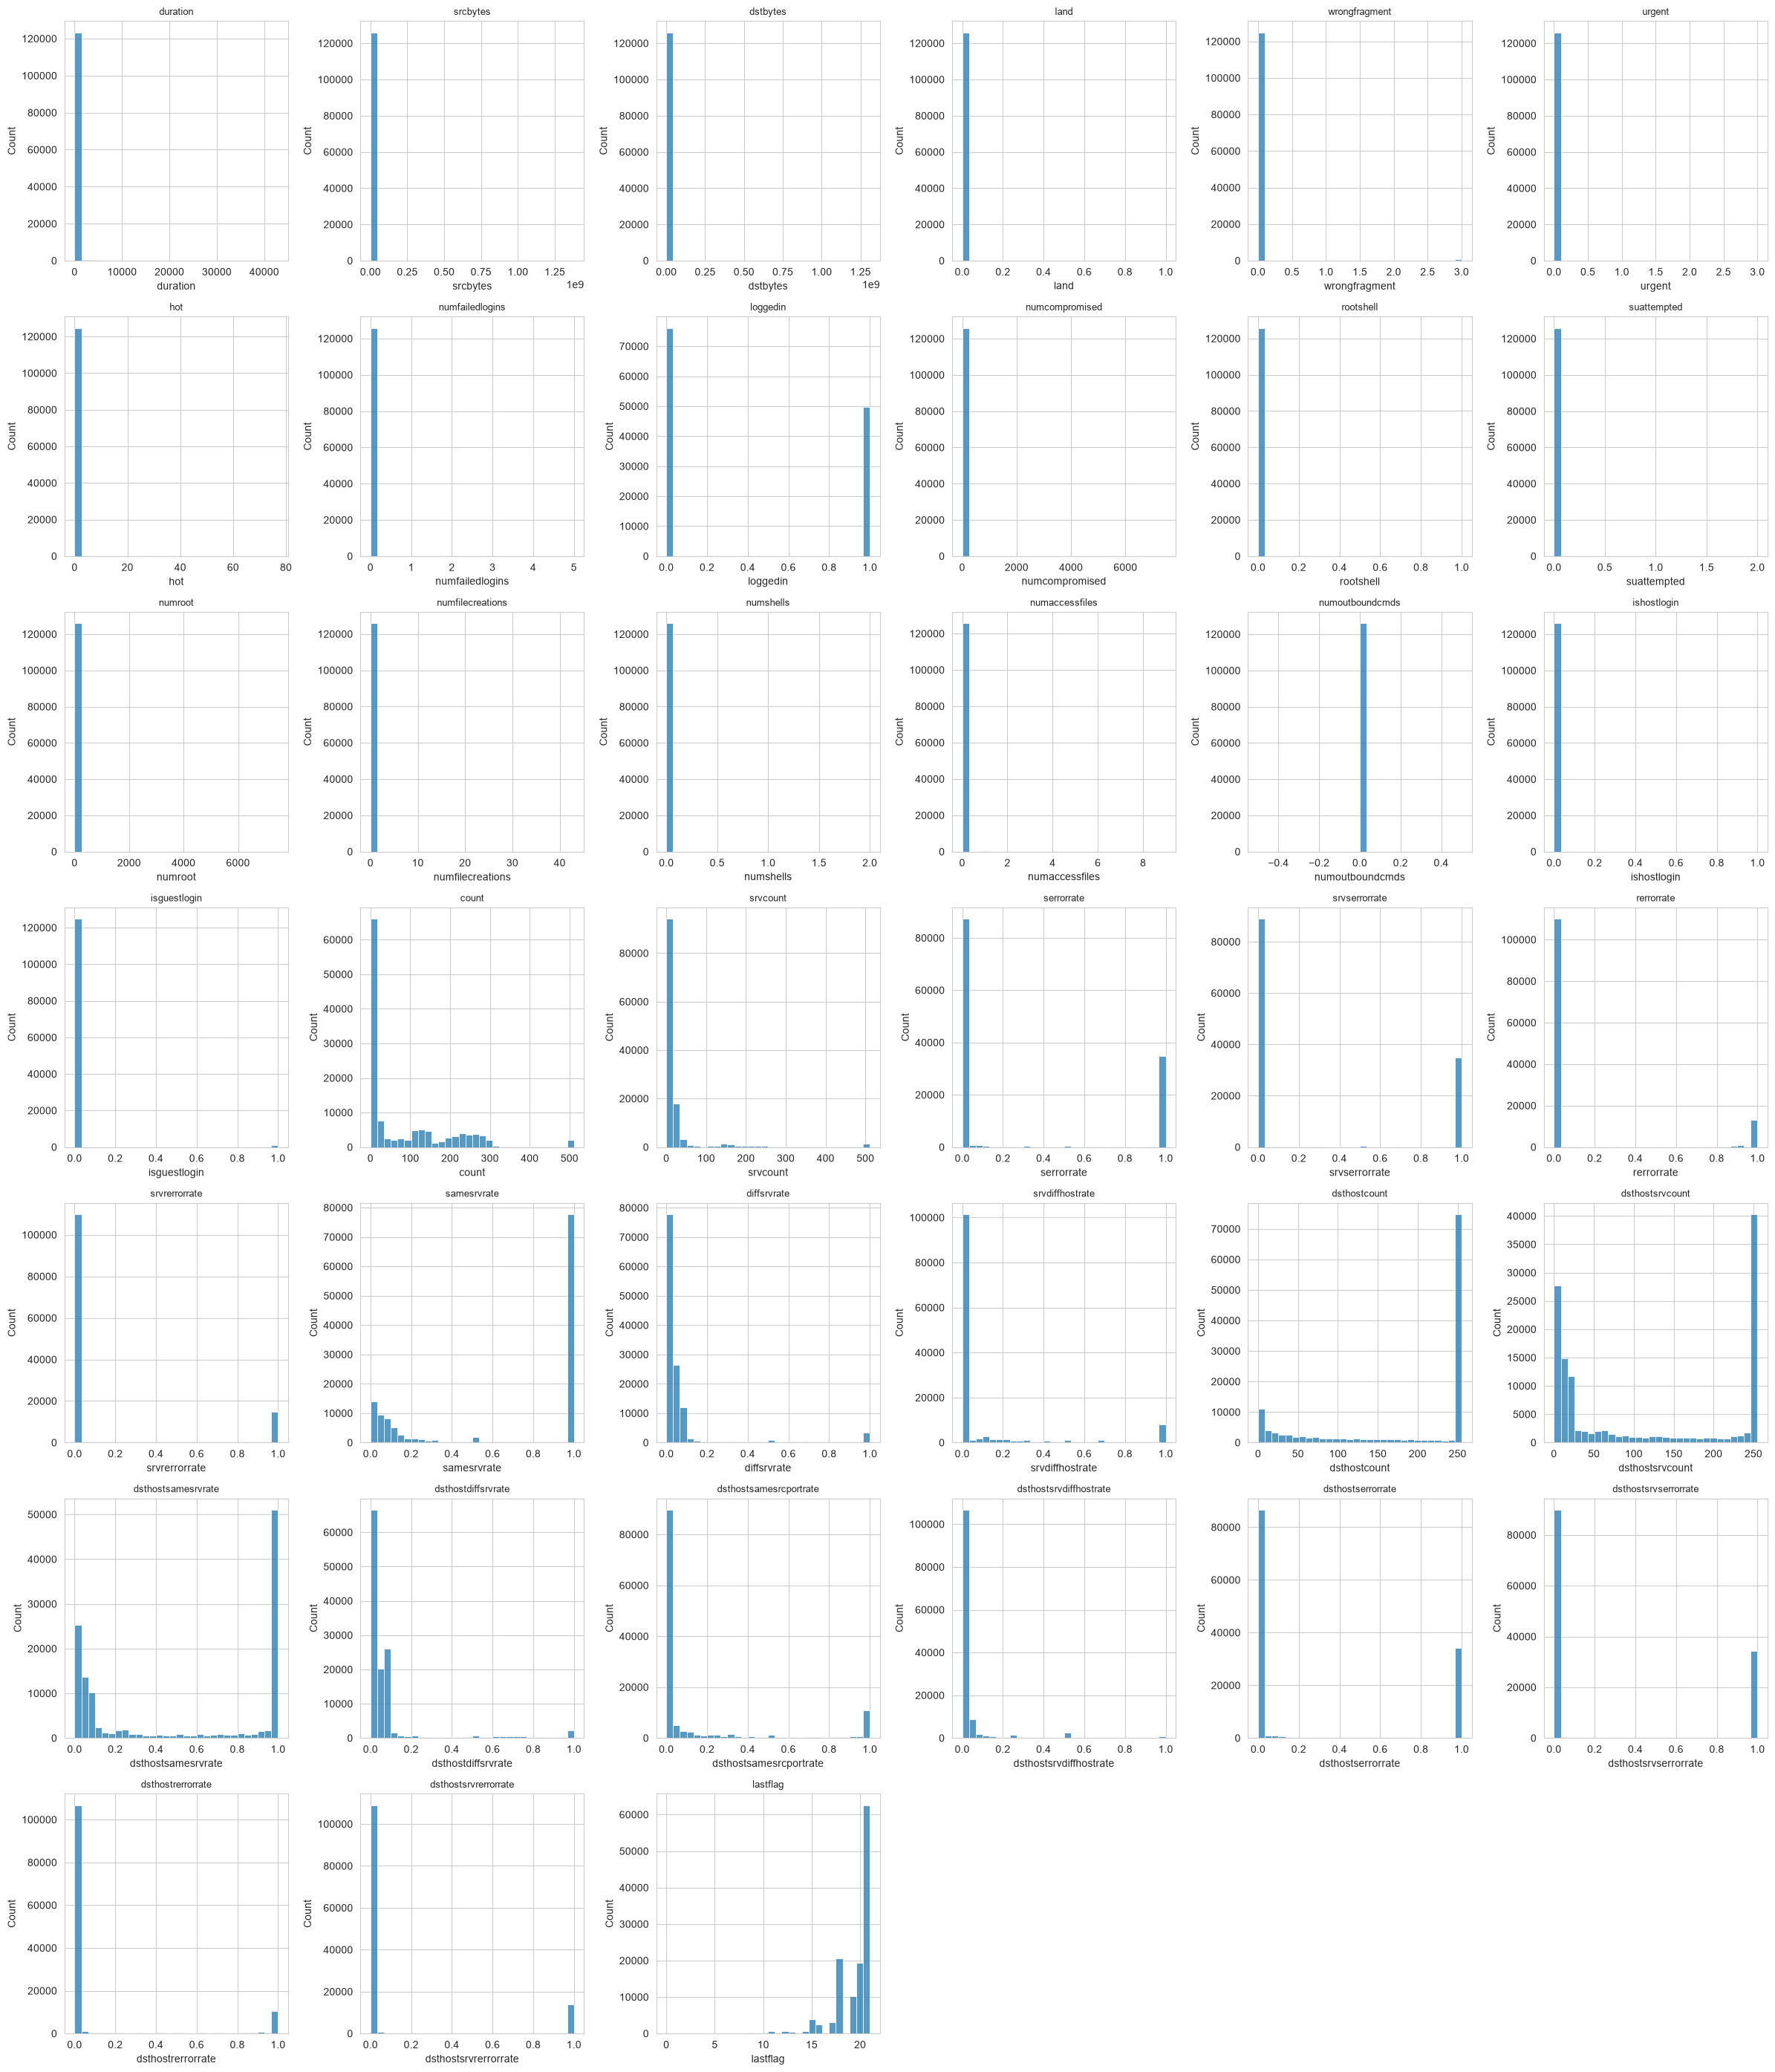

In [16]:
_DIST_SKIP = {
    "is_anomaly", "bytes_ratio", "total_error_rate",
    "srcbytes_log", "dstbytes_log", "duration_log",
}

def plot_distribution_grid(df, savefig):
    """Save a histogram grid for all retained numeric columns.
    Inlined from feature_engineering/distributions.py::plot_grid (Step 12)."""
    numeric_cols = [
        c for c in df.select_dtypes(include=[np.number]).columns
        if not c.startswith("is_") and c not in _DIST_SKIP
    ]
    n_cols = 6
    n_rows = int(np.ceil(len(numeric_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 4 * n_rows))
    axes = axes.flatten()
    for i, col in enumerate(numeric_cols):
        sns.histplot(df[col], bins=30, ax=axes[i])
        axes[i].set_title(col, fontsize=9)
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    savefig("full_distribution_grid.png")
    print(f"Plotted distributions for {len(numeric_cols)} numeric columns.")


def savefig(name):
    if SAVE_PLOTS:
        plt.savefig(os.path.join(PLOT_DIR, name), dpi=100, bbox_inches="tight")
    plt.close()

plot_distribution_grid(df, savefig)
show_plot("full_distribution_grid.png")


### 5.3 Dropping redundant / low-value features — `drop_redundant()` (inlined below, was `feature_engineering.cleanup.drop_redundant`)

- **`total_error_rate`** dropped — a pure linear combination (`serrorrate + rerrorrate`), structurally
  redundant with its two inputs.
- **`bytes_ratio`** dropped — **VIF ≈ 415** (severe multicollinearity) against a **correlation of only
  ≈0.006** with `is_anomaly`: maximal redundancy cost for essentially zero predictive value.
- **`numoutboundcmds`** dropped if constant (`nunique() <= 1`) — always 0 in this NSL-KDD release.


In [17]:
def drop_redundant(df):
    """Return df with the three redundant columns removed.
    Inlined from feature_engineering/cleanup.py::drop_redundant (Step 13)."""
    df = df.drop(columns=["total_error_rate"])
    print("\nDropped total_error_rate (redundant: serrorrate + rerrorrate).")

    df = df.drop(columns=["bytes_ratio"])
    print("Dropped bytes_ratio (VIF=415, correlation with is_anomaly ≈ 0.006).")

    if "numoutboundcmds" in df.columns and df["numoutboundcmds"].nunique() <= 1:
        df = df.drop(columns=["numoutboundcmds"])
        print("Dropped numoutboundcmds (zero variance — constant column).")
    return df

df = drop_redundant(df)



Dropped total_error_rate (redundant: serrorrate + rerrorrate).
Dropped bytes_ratio (VIF=415, correlation with is_anomaly ≈ 0.006).
Dropped numoutboundcmds (zero variance — constant column).


### 5.4 Variance Inflation Factor check — `check_vif()` (inlined below, was `feature_engineering.vif.check_vif`)

Diagnostic only (print-only, not an automated drop — see §6). **VIF > ~10 is the conventional
concerning-multicollinearity threshold.**


In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

_VIF_CANDIDATES = [
    "duration", "srcbytes", "dstbytes", "count", "srvcount",
    "serrorrate", "srvserrorrate", "rerrorrate", "srvrerrorrate",
    "samesrvrate", "diffsrvrate", "dsthostcount", "dsthostsrvcount",
    "dsthostsamesrvrate", "dsthostserrorrate",
    "is_s0_flag", "is_icmp", "is_zero_byte_conn",
]

def check_vif(df):
    """Print VIF for each candidate column present in df.
    Inlined from feature_engineering/vif.py::check_vif (Step 14). No files
    are written; output is printed only."""
    candidates = [c for c in _VIF_CANDIDATES if c in df.columns]
    vif_data = df[candidates].copy().replace([np.inf, -np.inf], 0).fillna(0)
    vif_results = pd.DataFrame({
        "feature": candidates,
        "VIF": [
            variance_inflation_factor(vif_data.values.astype(float), i)
            for i in range(len(candidates))
        ],
    })
    print("\n--- VIF — values above ~10 indicate concerning multicollinearity ---")
    print(vif_results.sort_values("VIF", ascending=False).to_string(index=False))

check_vif(df)



--- VIF — values above ~10 indicate concerning multicollinearity ---
           feature        VIF
     srvserrorrate 150.932746
        serrorrate 139.882791
     srvrerrorrate  68.942963
        rerrorrate  65.721206
        is_s0_flag  59.656517
 is_zero_byte_conn  51.564057
 dsthostserrorrate  44.668851
dsthostsamesrvrate  21.398688
   dsthostsrvcount  14.673015
       samesrvrate  10.236145
      dsthostcount   6.220169
             count   5.482162
          srvcount   2.993626
          duration   1.869310
           is_icmp   1.543691
       diffsrvrate   1.405533
          srcbytes   1.005314
          dstbytes   1.001541


### 5.5 Final correlation heatmap — `plot_heatmap()` (inlined below, was `feature_engineering.heatmap.plot_heatmap`)


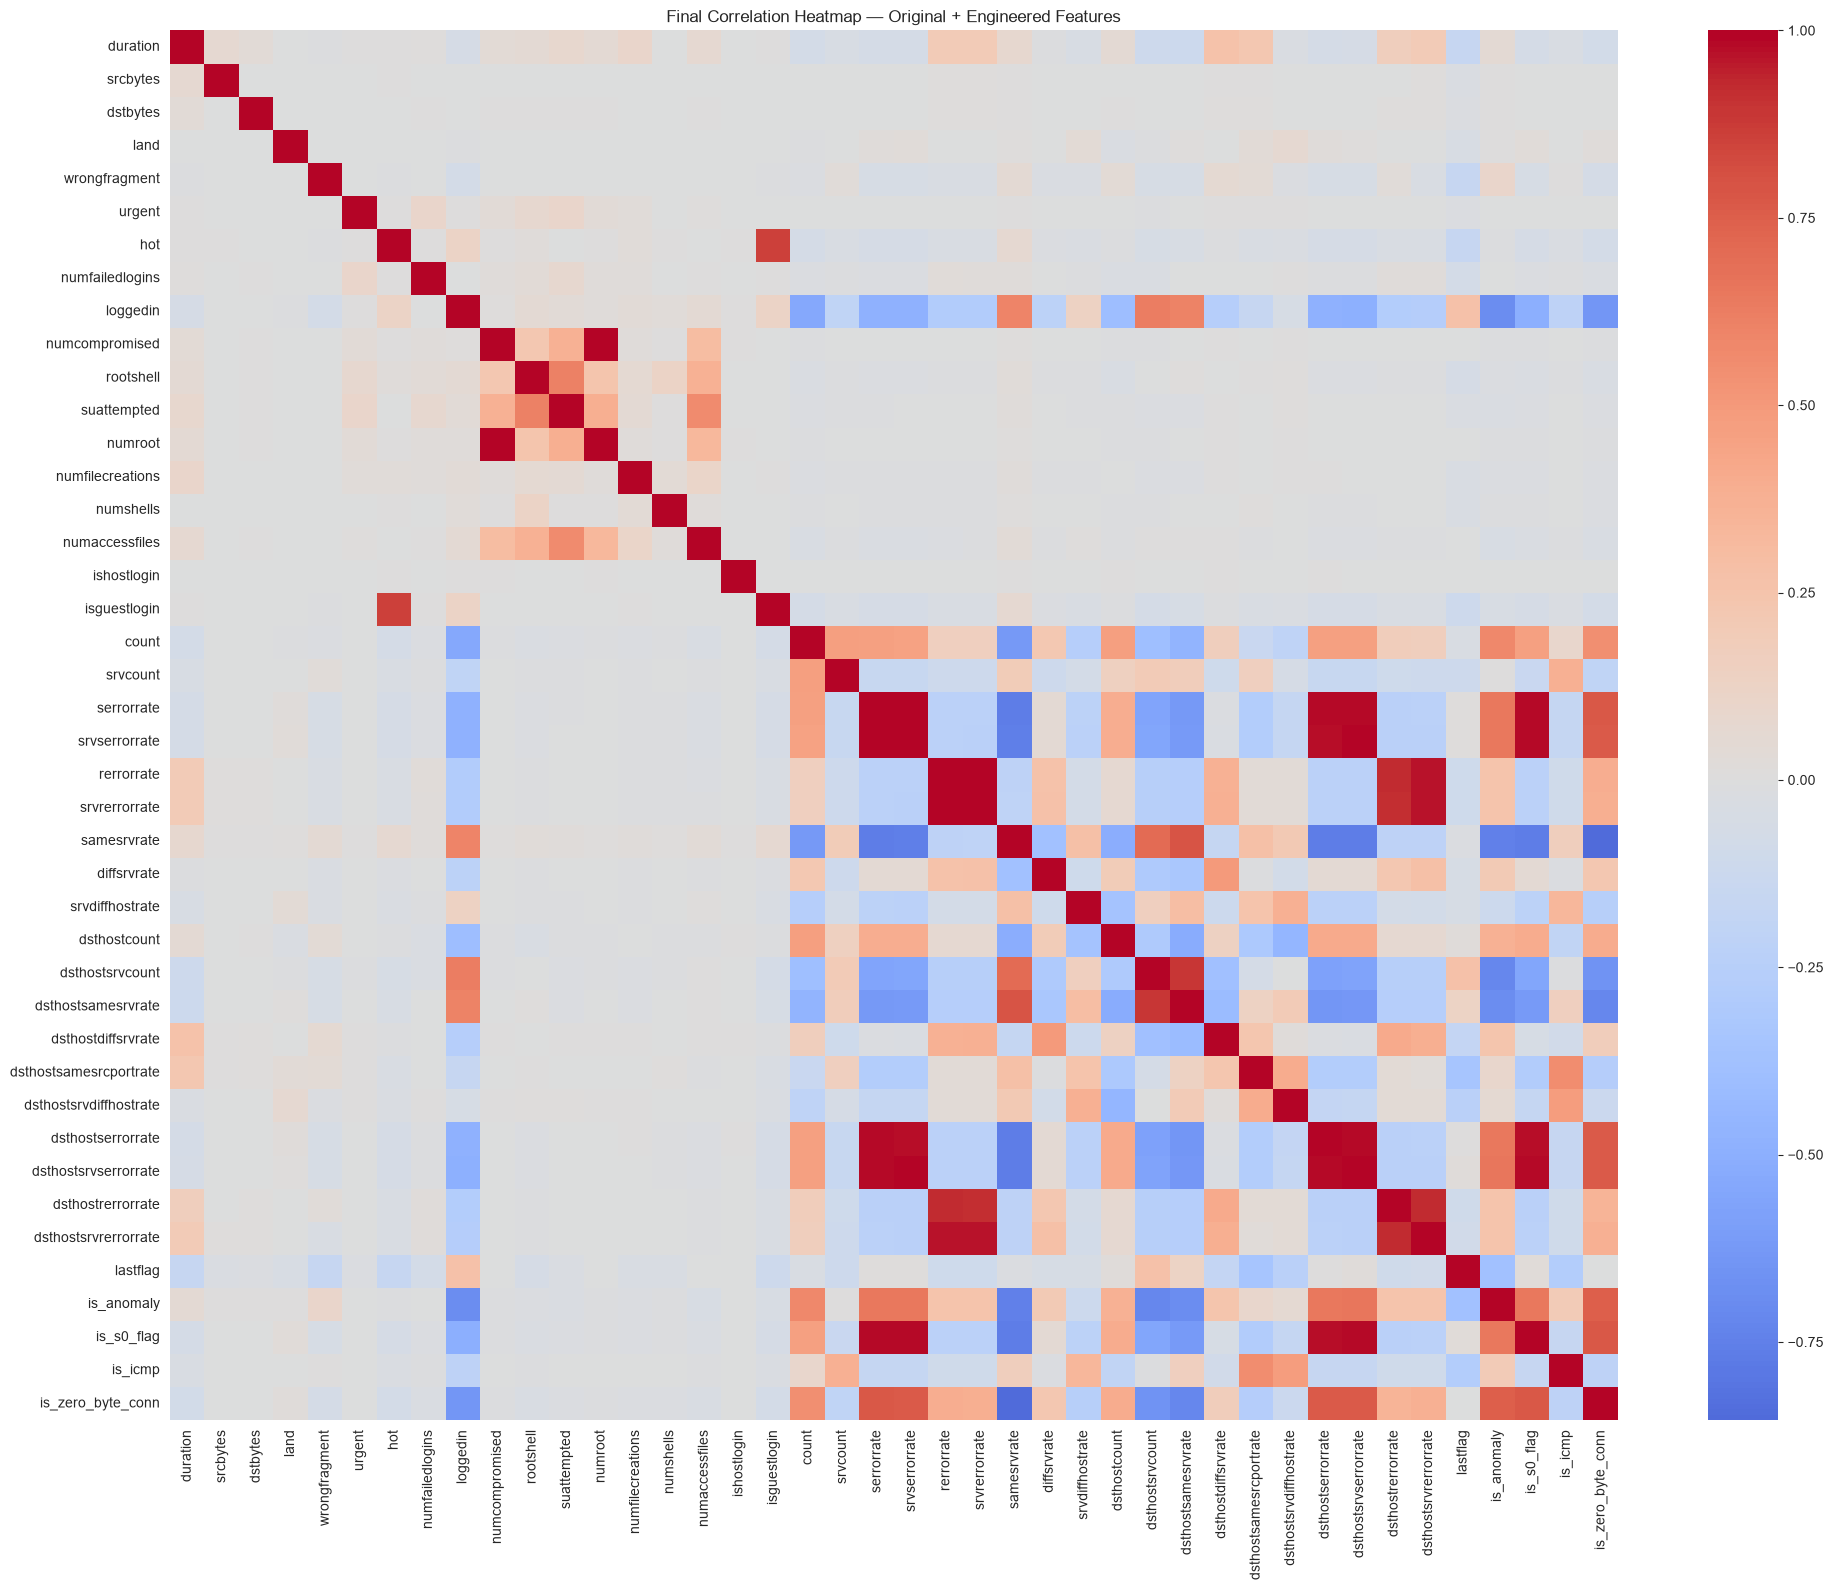

In [19]:
_HEATMAP_EXCLUDE = {"srcbytes_log", "dstbytes_log", "duration_log", "is_srcbytes_outlier"}

def plot_heatmap(df, savefig):
    """Save a correlation heatmap for all retained numeric columns.
    Inlined from feature_engineering/heatmap.py::plot_heatmap (Step 15)."""
    final_cols = [
        c for c in df.select_dtypes(include=[np.number]).columns
        if c not in _HEATMAP_EXCLUDE
    ]
    plt.figure(figsize=(20, 16))
    sns.heatmap(df[final_cols].corr(), cmap="coolwarm", center=0, annot=False)
    plt.title("Final Correlation Heatmap — Original + Engineered Features")
    plt.tight_layout()
    savefig("final_correlation_heatmap.png")

plot_heatmap(df, savefig)
show_plot("final_correlation_heatmap.png")


### 5.6 Final feature selection — `select_features()` (inlined below, was `feature_engineering.selector.select_features`)

Modeling input set: `protocoltype`, `service`, `flag` (encoded downstream) + 37 numeric NSL-KDD features +
the 3 engineered binary flags — **43 modeling features**, plus the two targets (`is_anomaly`, `attack`).


In [20]:
_EXPECTED_ENGINEERED = set(ENGINEERED_FEATURES)

def _assert_engineered_present(df):
    missing = _EXPECTED_ENGINEERED - set(df.columns)
    if missing:
        raise ValueError(
            f"select_features: expected engineered features {missing} to be present in df "
            f"but they are missing. Check add_features() and the column config in §1 are in sync."
        )

def select_features(df):
    """Return df filtered to exactly the columns needed for training.
    Column order matches MODELING_INPUT_COLS + TARGET_COLS (§1).
    Inlined from feature_engineering/selector.py::select_features (Step 16).
    Raises ValueError if engineered features are absent.
    """
    _assert_engineered_present(df)
    keep = [c for c in MODELING_INPUT_COLS if c in df.columns]
    print(f"\n--- STEP 16: FEATURE SELECTION ---")
    print(f"Retained {len(keep)} modeling columns + {len(TARGET_COLS)} targets.")
    return df[keep + TARGET_COLS].copy()

df_model = select_features(df)
print("df_model shape:", df_model.shape)



--- STEP 16: FEATURE SELECTION ---
Retained 43 modeling columns + 2 targets.
df_model shape: (125973, 45)


## 6. Feature Engineering Insights & Recommendations

**Key insights**

1. Structural/statistical pruning (linear-combination removal, VIF, zero-variance) removed 3 columns while
   keeping every feature with real, non-redundant signal — the `bytes_ratio` case (VIF 415, correlation
   0.006) is a clean example of a feature that *looks* clever (a ratio) but is almost pure noise once its
   two inputs are already in the model.
2. All three engineered binary flags (`is_s0_flag`, `is_icmp`, `is_zero_byte_conn`) show a non-trivial
   correlation with `is_anomaly` and cost nothing in multicollinearity — cheap, interpretable wins.
3. The VIF check is currently **diagnostic/print-only** — it informs a documented drop decision
   (`bytes_ratio`) but isn't wired to auto-drop any column that crosses the threshold at run time.

**Recommendations**

- Wire the VIF check into an **automatic** drop step (e.g. iteratively remove the highest-VIF column above
  10 and recompute) so future feature additions can't silently reintroduce severe multicollinearity without
  a human noticing the printed table.
- Consider a formal pairwise-correlation-threshold drop (e.g. `|corr| > 0.9`) as a second automated pass —
  today, the final correlation heatmap is visual-only and no such threshold is enforced in code.
- Re-validate feature importance periodically as new attack types are added to training data — a feature
  that's redundant on today's mix of 23 attack types might become informative once new attack families
  appear.


## 7. ML Modeling — Binary Classification (`is_anomaly`)

From here on, every cell instantiates the inlined `TrainingState` class (the same shared-context object
`trainer/__init__.py::train_all()` threads through every step in the real pipeline) and calls one inlined
trainer step function — `prepare_splits`, `train_binary`, `run_cross_validation`, `tune_threshold`,
`train_isolation_forest`, `summarize_binary` — reproducing, in the exact sequence `train_all()` calls the
real step modules internally, the logic that originally lived in `trainer.splitter.prepare_splits`,
`trainer.binary_models.train_binary`, `trainer.cross_validation.run_cross_validation`,
`trainer.threshold.tune_threshold`, `trainer.isolation_forest.train_isolation_forest`, and
`trainer.binary_summary.summarize_binary`.

> **This section trains the full model suite** (Logistic Regression, Decision Tree, Random Forest, SVM,
> MLP, XGBoost baseline + tuned, Stacking Ensemble, Isolation Forest) — 20-40 minutes on the full dataset,
> same as the dashboard's Train Pipeline tab.

### 7.1 Encoding, split, scaling — `prepare_splits()` (inlined below, was `trainer.splitter.prepare_splits`)


In [21]:
class TrainingState:
    """Mutable training context passed between pipeline step functions.
    Inlined from trainer/state.py::TrainingState -- identical shared-context
    object the real trainer/__init__.py::train_all() threads through every
    step."""

    def __init__(self, df_model, model_dir, save_plots, plot_dir):
        self.df_model   = df_model
        self.model_dir  = model_dir
        self.save_plots = save_plots
        self.plot_dir   = plot_dir

        # ------------------------------------------------------------
        # prepare_splits output
        # ------------------------------------------------------------
        self.X_train        = None
        self.X_test         = None
        self.X_train_raw    = None
        self.X_test_raw     = None
        self.y_train        = None
        self.y_test          = None
        self.attack_train   = None
        self.attack_test    = None
        self.X_train_scaled = None
        self.X_test_scaled  = None
        self.scaler         = None
        self.service_freq_map = None
        self.fallback_freq  = None
        self.scale_pos_weight = None

        # ------------------------------------------------------------
        # train_binary output
        # ------------------------------------------------------------
        self.binary_models = {}
        self.binary_preds  = {}
        self.binary_probas = {}
        self.xgb_model     = None

        # ------------------------------------------------------------
        # tune_threshold output
        # ------------------------------------------------------------
        self.chosen_threshold    = 0.5
        self.y_pred_recall_tuned = None

        # ------------------------------------------------------------
        # summarize_binary output
        # ------------------------------------------------------------
        self.results_df = None

        # ------------------------------------------------------------
        # train_multiclass output
        # ------------------------------------------------------------
        self.le_attack       = None
        self.xgb_multi       = None
        self.best_multi_name = None

        # ------------------------------------------------------------
        # train_unsupervised output
        # ------------------------------------------------------------
        self.pca_recon       = None
        self.recon_auc       = None
        self.recon_threshold = None

    def savefig(self, name):
        """Save the current matplotlib figure to plot_dir and close it.

        Writes to a temp file first, then atomically renames it into place
        (os.replace). matplotlib's savefig() is NOT atomic -- it writes
        bytes to the destination incrementally before closing -- and every
        training run regenerates the exact same plot filenames in plot_dir.
        Without this, a concurrent reader of one of these files could read
        a half-written, corrupt PNG mid-save. os.replace() on the same
        filesystem is atomic, so a reader only ever sees the complete old
        file or the complete new one, never a partial write.
        """
        import matplotlib.pyplot as _plt
        if self.save_plots:
            final_path = os.path.join(self.plot_dir, name)
            tmp_path = os.path.join(self.plot_dir, f".{name}.tmp")
            _plt.savefig(tmp_path, dpi=100, bbox_inches="tight", format="png")
            os.replace(tmp_path, final_path)
        _plt.close()


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def prepare_splits(state):
    """Step 1 -- one-hot encode categorical columns, train/test split, scale.
    Inlined from trainer/splitter.py::prepare_splits.

    Writes to state:
      X_train, X_test, X_train_raw, X_test_raw
      y_train, y_test, attack_train, attack_test
      X_train_scaled, X_test_scaled
      scaler, service_freq_map, fallback_freq, scale_pos_weight
    """
    print("\n" + "=" * 70)
    print("STEP 1: DATA ENCODING, SPLIT, SCALING")
    print("=" * 70)

    df_enc = pd.get_dummies(state.df_model.copy(),
                            columns=["protocoltype", "flag"], drop_first=True)
    print(f"Shape after one-hot encoding: {df_enc.shape}")

    X_raw         = df_enc.drop(columns=["is_anomaly", "attack"])
    y_binary      = df_enc["is_anomaly"]
    attack_labels = df_enc["attack"]

    (state.X_train_raw, state.X_test_raw,
     state.y_train, state.y_test,
     state.attack_train, state.attack_test) = train_test_split(
        X_raw, y_binary, attack_labels,
        test_size=0.2, stratify=y_binary, random_state=RANDOM_STATE,
    )

    # Frequency-encode service on TRAIN only (no leakage)
    state.service_freq_map = state.X_train_raw["service"].value_counts(normalize=True)
    state.fallback_freq    = state.service_freq_map.min()

    state.X_train = state.X_train_raw.copy()
    state.X_test  = state.X_test_raw.copy()
    state.X_train["service_freq"] = state.X_train["service"].map(state.service_freq_map)
    state.X_test["service_freq"]  = (
        state.X_test["service"].map(state.service_freq_map).fillna(state.fallback_freq)
    )
    state.X_train = state.X_train.drop(columns=["service"])
    state.X_test  = state.X_test.drop(columns=["service"])
    print(f"Train shape: {state.X_train.shape}, Test shape: {state.X_test.shape}")

    state.scaler = StandardScaler()
    state.X_train_scaled = state.scaler.fit_transform(state.X_train)
    state.X_test_scaled  = state.scaler.transform(state.X_test)
    state.scale_pos_weight = (
        (state.y_train == 0).sum() / (state.y_train == 1).sum()
    )

state = TrainingState(df_model, model_dir=MODEL_DIR, save_plots=SAVE_PLOTS, plot_dir=PLOT_DIR)
prepare_splits(state)



STEP 1: DATA ENCODING, SPLIT, SCALING
Shape after one-hot encoding: (125973, 55)
Train shape: (100778, 53), Test shape: (25195, 53)


One-hot encodes `protocoltype`/`flag` (`drop_first=True`), frequency-encodes `service` on the TRAIN
split only (no leakage), stratified 80/20 split (informed by §2.10's temporal-structure finding — not
chronological), `StandardScaler` fit on train only, and computes `scale_pos_weight` for XGBoost's class
imbalance correction.

### 7.2 Binary classifiers — `train_binary()` (inlined below, was `trainer.binary_models.train_binary`)

Trains Logistic Regression, Decision Tree, Random Forest, SVM (LinearSVC + calibrated), Neural Network
(MLP), XGBoost (baseline), XGBoost (tuned via `RandomizedSearchCV`, 20 iterations), and a Stacking
Ensemble — every hyperparameter exactly as configured in the original `trainer/binary_models.py`.


In [22]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score
import xgboost as xgb

def train_binary(state):
    """Step 2 -- train all binary supervised classification models.
    Inlined from trainer/binary_models.py::train_binary.

    Models trained: Logistic Regression, Decision Tree, Random Forest,
    SVM (LinearSVC + CalibratedClassifierCV), Neural Network (MLP),
    XGBoost (baseline), XGBoost (tuned via RandomizedSearchCV),
    Stacking Ensemble (LR + DT + RF -> LR meta-learner).

    Writes to state: binary_models, binary_preds, binary_probas, xgb_model
    """
    print("\n" + "#" * 70)
    print("# SUPERVISED MODELS — BINARY (is_anomaly)")
    print("#" * 70)

    def fit_eval(name, model, X_tr, y_tr, X_te, y_te):
        model.fit(X_tr, y_tr)
        preds = model.predict(X_te)
        proba = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None
        print(f"\n{'=' * 70}\n{name}\n{'=' * 70}")
        print(classification_report(y_te, preds, target_names=["Normal", "Anomaly"]))
        if proba is not None:
            print(f"ROC-AUC: {roc_auc_score(y_te, proba):.4f}")
        state.binary_models[name] = model
        state.binary_preds[name]  = preds
        state.binary_probas[name] = proba

    fit_eval(
        "Logistic Regression",
        LogisticRegression(penalty="l2", C=1.0, max_iter=1000, random_state=RANDOM_STATE),
        state.X_train_scaled, state.y_train, state.X_test_scaled, state.y_test,
    )
    fit_eval(
        "Decision Tree",
        DecisionTreeClassifier(max_depth=15, min_samples_leaf=5,
                                class_weight="balanced", random_state=RANDOM_STATE),
        state.X_train, state.y_train, state.X_test, state.y_test,
    )
    fit_eval(
        "Random Forest",
        RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_leaf=5,
                                class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
        state.X_train, state.y_train, state.X_test, state.y_test,
    )

    print("\nTraining SVM (LinearSVC) — may take a few minutes…")
    fit_eval(
        "SVM (Linear, calibrated)",
        CalibratedClassifierCV(
            LinearSVC(C=1.0, class_weight="balanced", max_iter=5000,
                      random_state=RANDOM_STATE),
            method="sigmoid", cv=3,
        ),
        state.X_train_scaled, state.y_train, state.X_test_scaled, state.y_test,
    )

    print("\nTraining Neural Network (MLP) — may take a few minutes…")
    fit_eval(
        "Neural Network (MLP)",
        MLPClassifier(
            hidden_layer_sizes=(64, 32), activation="relu", solver="adam",
            alpha=1e-4, batch_size=256, max_iter=100, early_stopping=True,
            n_iter_no_change=10, random_state=RANDOM_STATE,
        ),
        state.X_train_scaled, state.y_train, state.X_test_scaled, state.y_test,
    )

    fit_eval(
        "XGBoost (baseline)",
        xgb.XGBClassifier(
            n_estimators=300, max_depth=8, learning_rate=0.1,
            scale_pos_weight=state.scale_pos_weight, eval_metric="logloss",
            random_state=RANDOM_STATE, n_jobs=-1,
        ),
        state.X_train, state.y_train, state.X_test, state.y_test,
    )

    print("\n" + "=" * 70)
    print("XGBoost — Hyperparameter Tuning (RandomizedSearchCV)")
    print("=" * 70)
    param_dist = {
        "n_estimators":     [150, 200, 300, 400],
        "max_depth":        [4, 6, 8, 10],
        "learning_rate":    [0.01, 0.05, 0.1, 0.2],
        "subsample":        [0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
        "min_child_weight": [1, 3, 5],
    }
    search = RandomizedSearchCV(
        xgb.XGBClassifier(scale_pos_weight=state.scale_pos_weight,
                          eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1),
        param_distributions=param_dist, n_iter=20, scoring="f1",
        cv=3, random_state=RANDOM_STATE, n_jobs=-1, verbose=1,
    )
    search.fit(state.X_train, state.y_train)
    print(f"Best params: {search.best_params_}")
    print(f"Best CV F1:  {search.best_score_:.4f}")
    state.xgb_model = search.best_estimator_
    fit_eval("XGBoost (tuned)", state.xgb_model,
             state.X_train, state.y_train, state.X_test, state.y_test)

    importance = pd.DataFrame({
        "feature":    state.X_train.columns,
        "importance": state.xgb_model.feature_importances_,
    }).sort_values("importance", ascending=False)
    print("\nTop 15 XGBoost feature importances:")
    print(importance.head(15))
    plt.figure(figsize=(10, 7))
    importance.head(20).set_index("feature")["importance"].sort_values().plot(kind="barh")
    plt.title("XGBoost (tuned) — Top 20 Feature Importances")
    plt.tight_layout()
    state.savefig("xgb_feature_importance.png")

    print("\n" + "=" * 70)
    print("Stacking Ensemble (LR + DT + RF → LR meta-learner)")
    print("=" * 70)
    fit_eval(
        "Stacking Ensemble",
        StackingClassifier(
            estimators=[
                ("logreg", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
                ("dtree",  DecisionTreeClassifier(max_depth=15, min_samples_leaf=5,
                                                  random_state=RANDOM_STATE)),
                ("rf",     RandomForestClassifier(n_estimators=100, max_depth=15,
                                                   random_state=RANDOM_STATE, n_jobs=-1)),
            ],
            final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
            cv=3, n_jobs=-1,
        ),
        state.X_train, state.y_train, state.X_test, state.y_test,
    )

train_binary(state)



######################################################################
# SUPERVISED MODELS — BINARY (is_anomaly)
######################################################################

Logistic Regression
              precision    recall  f1-score   support

      Normal       0.95      0.97      0.96     13469
     Anomaly       0.96      0.94      0.95     11726

    accuracy                           0.96     25195
   macro avg       0.96      0.95      0.96     25195
weighted avg       0.96      0.96      0.96     25195

ROC-AUC: 0.9934

Decision Tree
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
     Anomaly       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195

ROC-AUC: 0.9993

Random Forest
              precision    recall  f1-score   support

      Normal       1.00

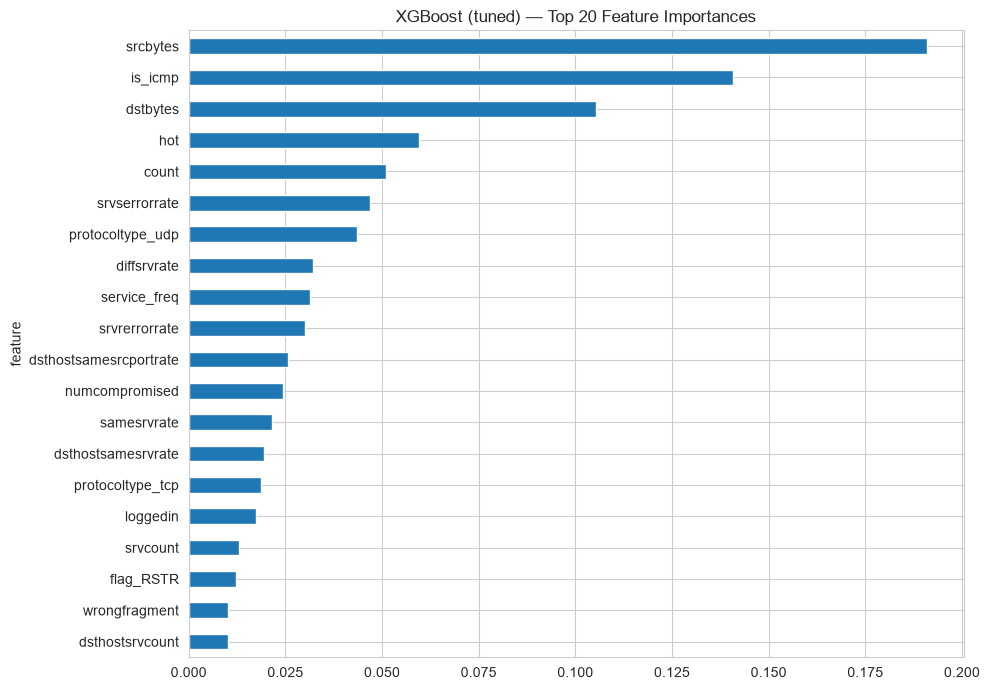

In [23]:
show_plot("xgb_feature_importance.png")


### 7.3 Cross-validation — `run_cross_validation()` (inlined below, was `trainer.cross_validation.run_cross_validation`)

Stratified 5-fold on the 4 fastest models, to confirm the held-out test-set scores aren't a lucky split.


In [24]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

def run_cross_validation(state):
    """Step 3 -- stratified 5-fold cross-validation for the four fast models.
    Inlined from trainer/cross_validation.py::run_cross_validation."""
    print("\n" + "=" * 70)
    print("CROSS-VALIDATION — Stratified 5-Fold (fast models only)")
    print("=" * 70)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    targets = {
        "Logistic Regression": (
            LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
            state.X_train_scaled,
        ),
        "Decision Tree": (
            DecisionTreeClassifier(max_depth=15, min_samples_leaf=5,
                                    random_state=RANDOM_STATE),
            state.X_train,
        ),
        "Random Forest": (
            RandomForestClassifier(n_estimators=200, max_depth=20,
                                    random_state=RANDOM_STATE, n_jobs=-1),
            state.X_train,
        ),
        "XGBoost (tuned)": (state.xgb_model, state.X_train),
    }
    cv_rows = []
    for name, (est, X_data) in targets.items():
        f1  = cross_val_score(est, X_data, state.y_train, cv=skf,
                              scoring="f1",      n_jobs=-1)
        auc = cross_val_score(est, X_data, state.y_train, cv=skf,
                              scoring="roc_auc", n_jobs=-1)
        print(f"{name}: F1={f1.mean():.4f}±{f1.std():.4f}  "
              f"AUC={auc.mean():.4f}±{auc.std():.4f}")
        cv_rows.append({
            "Model":     name,
            "CV F1":     round(float(f1.mean()), 4),
            "F1 Std":    round(float(f1.std()),  4),
            "CV ROC-AUC": round(float(auc.mean()), 4),
            "AUC Std":   round(float(auc.std()),  4),
        })

    best_cv = max(cv_rows, key=lambda r: r["CV F1"])["Model"]
    cv_comp = {"best": best_cv, "models": cv_rows}
    cv_path = os.path.join(state.model_dir, "cv_comparison.json")
    with open(cv_path, "w") as _f:
        json.dump(cv_comp, _f, indent=2)
    print(f"  Saved: cv_comparison.json")

run_cross_validation(state)



CROSS-VALIDATION — Stratified 5-Fold (fast models only)
Logistic Regression: F1=0.9548±0.0019  AUC=0.9932±0.0004
Decision Tree: F1=0.9973±0.0004  AUC=0.9990±0.0002
Random Forest: F1=0.9985±0.0001  AUC=1.0000±0.0000
XGBoost (tuned): F1=0.9990±0.0002  AUC=1.0000±0.0000
  Saved: cv_comparison.json


### 7.4 Decision threshold tuning — `tune_threshold()` (inlined below, was `trainer.threshold.tune_threshold`)

The default 0.5 cutoff isn't necessarily the best operating point for a security tool. Scans the tuned
XGBoost's precision/recall curve for the highest threshold that still holds recall ≥ 99%.


In [25]:
from sklearn.metrics import precision_recall_curve, precision_recall_fscore_support

def tune_threshold(state):
    """Step 4 -- decision threshold tuning for XGBoost (tuned).
    Inlined from trainer/threshold.py::tune_threshold.

    Finds the highest threshold that still achieves >=99% recall, saving a
    precision/recall-vs-threshold plot.

    Writes to state: chosen_threshold, y_pred_recall_tuned
    """
    print("\n" + "=" * 70)
    print("DECISION THRESHOLD TUNING (XGBoost, tuned)")
    print("=" * 70)
    y_proba = state.binary_probas["XGBoost (tuned)"]
    precisions, recalls, thresholds = precision_recall_curve(state.y_test, y_proba)

    plt.figure(figsize=(8, 6))
    plt.plot(thresholds, precisions[:-1], label="Precision")
    plt.plot(thresholds, recalls[:-1],    label="Recall")
    plt.axvline(0.5, color="gray", linestyle="--", label="Default (0.5)")
    plt.xlabel("Decision Threshold")
    plt.ylabel("Score")
    plt.title("Precision / Recall vs. Decision Threshold — XGBoost")
    plt.legend()
    plt.tight_layout()
    state.savefig("threshold_tuning.png")

    target_recall = 0.99
    candidates = [
        (t, p, r)
        for t, p, r in zip(thresholds, precisions[:-1], recalls[:-1])
        if r >= target_recall
    ]
    if candidates:
        state.chosen_threshold, _, _ = max(candidates, key=lambda x: x[0])
    else:
        idx = np.argmax(recalls[:-1])
        state.chosen_threshold = float(thresholds[idx]) if idx < len(thresholds) else 0.5

    state.y_pred_recall_tuned = (y_proba >= state.chosen_threshold).astype(int)
    p_new, r_new, f_new, _ = precision_recall_fscore_support(
        state.y_test, state.y_pred_recall_tuned, average="binary"
    )
    print(f"Recall-favoring threshold ({state.chosen_threshold:.4f}): "
          f"P={p_new:.4f}  R={r_new:.4f}  F1={f_new:.4f}")

tune_threshold(state)



DECISION THRESHOLD TUNING (XGBoost, tuned)
Recall-favoring threshold (0.9963): P=1.0000  R=0.9900  F1=0.9950


### 7.5 Isolation Forest (honest unsupervised baseline) — `train_isolation_forest()` (inlined below, was `trainer.isolation_forest.train_isolation_forest`)

Trained on **normal-only** traffic, at two honesty levels: `contamination='auto'` and a disclosed
true-anomaly-rate benchmark. Included specifically as a "what could we do with zero labeled attacks"
lower bound, not a deployment candidate.


In [26]:
from sklearn.ensemble import IsolationForest

def train_isolation_forest(state):
    """Step 5 -- Isolation Forest (trained on normal-only traffic).
    Inlined from trainer/isolation_forest.py::train_isolation_forest.

    Two variants are evaluated:
      (a) Honest unsupervised  -- contamination='auto'
      (b) Disclosed benchmark  -- contamination=true anomaly rate

    Writes to state:
      binary_preds["Isolation Forest (auto)"]
      binary_preds["Isolation Forest (true-rate benchmark)"]
    """
    print("\n" + "=" * 70)
    print("Isolation Forest (trained on normal-only traffic)")
    print("=" * 70)
    X_normal = state.X_train[state.y_train == 0]

    print("\n--- (a) Honest unsupervised: contamination='auto' ---")
    iso_auto = IsolationForest(n_estimators=200, contamination="auto",
                                random_state=RANDOM_STATE, n_jobs=-1)
    iso_auto.fit(X_normal)
    y_auto = np.where(iso_auto.predict(state.X_test) == -1, 1, 0)
    print(classification_report(state.y_test, y_auto, target_names=["Normal", "Anomaly"]))
    state.binary_preds["Isolation Forest (auto)"] = y_auto

    print("\n--- (b) DISCLOSED benchmark: contamination=true anomaly rate ---")
    iso_bench = IsolationForest(n_estimators=200, contamination=state.y_train.mean(),
                                  random_state=RANDOM_STATE, n_jobs=-1)
    iso_bench.fit(X_normal)
    y_bench = np.where(iso_bench.predict(state.X_test) == -1, 1, 0)
    print(classification_report(state.y_test, y_bench, target_names=["Normal", "Anomaly"]))
    state.binary_preds["Isolation Forest (true-rate benchmark)"] = y_bench

train_isolation_forest(state)



Isolation Forest (trained on normal-only traffic)

--- (a) Honest unsupervised: contamination='auto' ---
              precision    recall  f1-score   support

      Normal       0.92      0.93      0.92     13469
     Anomaly       0.92      0.91      0.91     11726

    accuracy                           0.92     25195
   macro avg       0.92      0.92      0.92     25195
weighted avg       0.92      0.92      0.92     25195


--- (b) DISCLOSED benchmark: contamination=true anomaly rate ---
              precision    recall  f1-score   support

      Normal       1.00      0.54      0.70     13469
     Anomaly       0.65      1.00      0.79     11726

    accuracy                           0.75     25195
   macro avg       0.83      0.77      0.74     25195
weighted avg       0.84      0.75      0.74     25195



### 7.6 Model comparison summary — `summarize_binary()` (inlined below, was `trainer.binary_summary.summarize_binary`)

Builds the comparison table, confusion matrices, and ROC curves across every binary model above.



MODEL COMPARISON SUMMARY (binary is_anomaly)
                                     Model  Accuracy     F1  Precision  Recall  ROC-AUC
                       Logistic Regression    0.9554 0.9517     0.9599  0.9436   0.9934
                             Decision Tree    0.9982 0.9980     0.9976  0.9985   0.9993
                             Random Forest    0.9984 0.9983     0.9991  0.9974   1.0000
                  SVM (Linear, calibrated)    0.9569 0.9533     0.9609  0.9458   0.9931
                      Neural Network (MLP)    0.9957 0.9953     0.9959  0.9948   0.9998
                        XGBoost (baseline)    0.9993 0.9993     0.9991  0.9994   1.0000
                           XGBoost (tuned)    0.9992 0.9991     0.9991  0.9991   1.0000
                         Stacking Ensemble    0.9990 0.9989     0.9990  0.9988   1.0000
                   Isolation Forest (auto)    0.9188 0.9124     0.9168  0.9080      NaN
    Isolation Forest (true-rate benchmark)    0.7519 0.7895     0.6523  0.

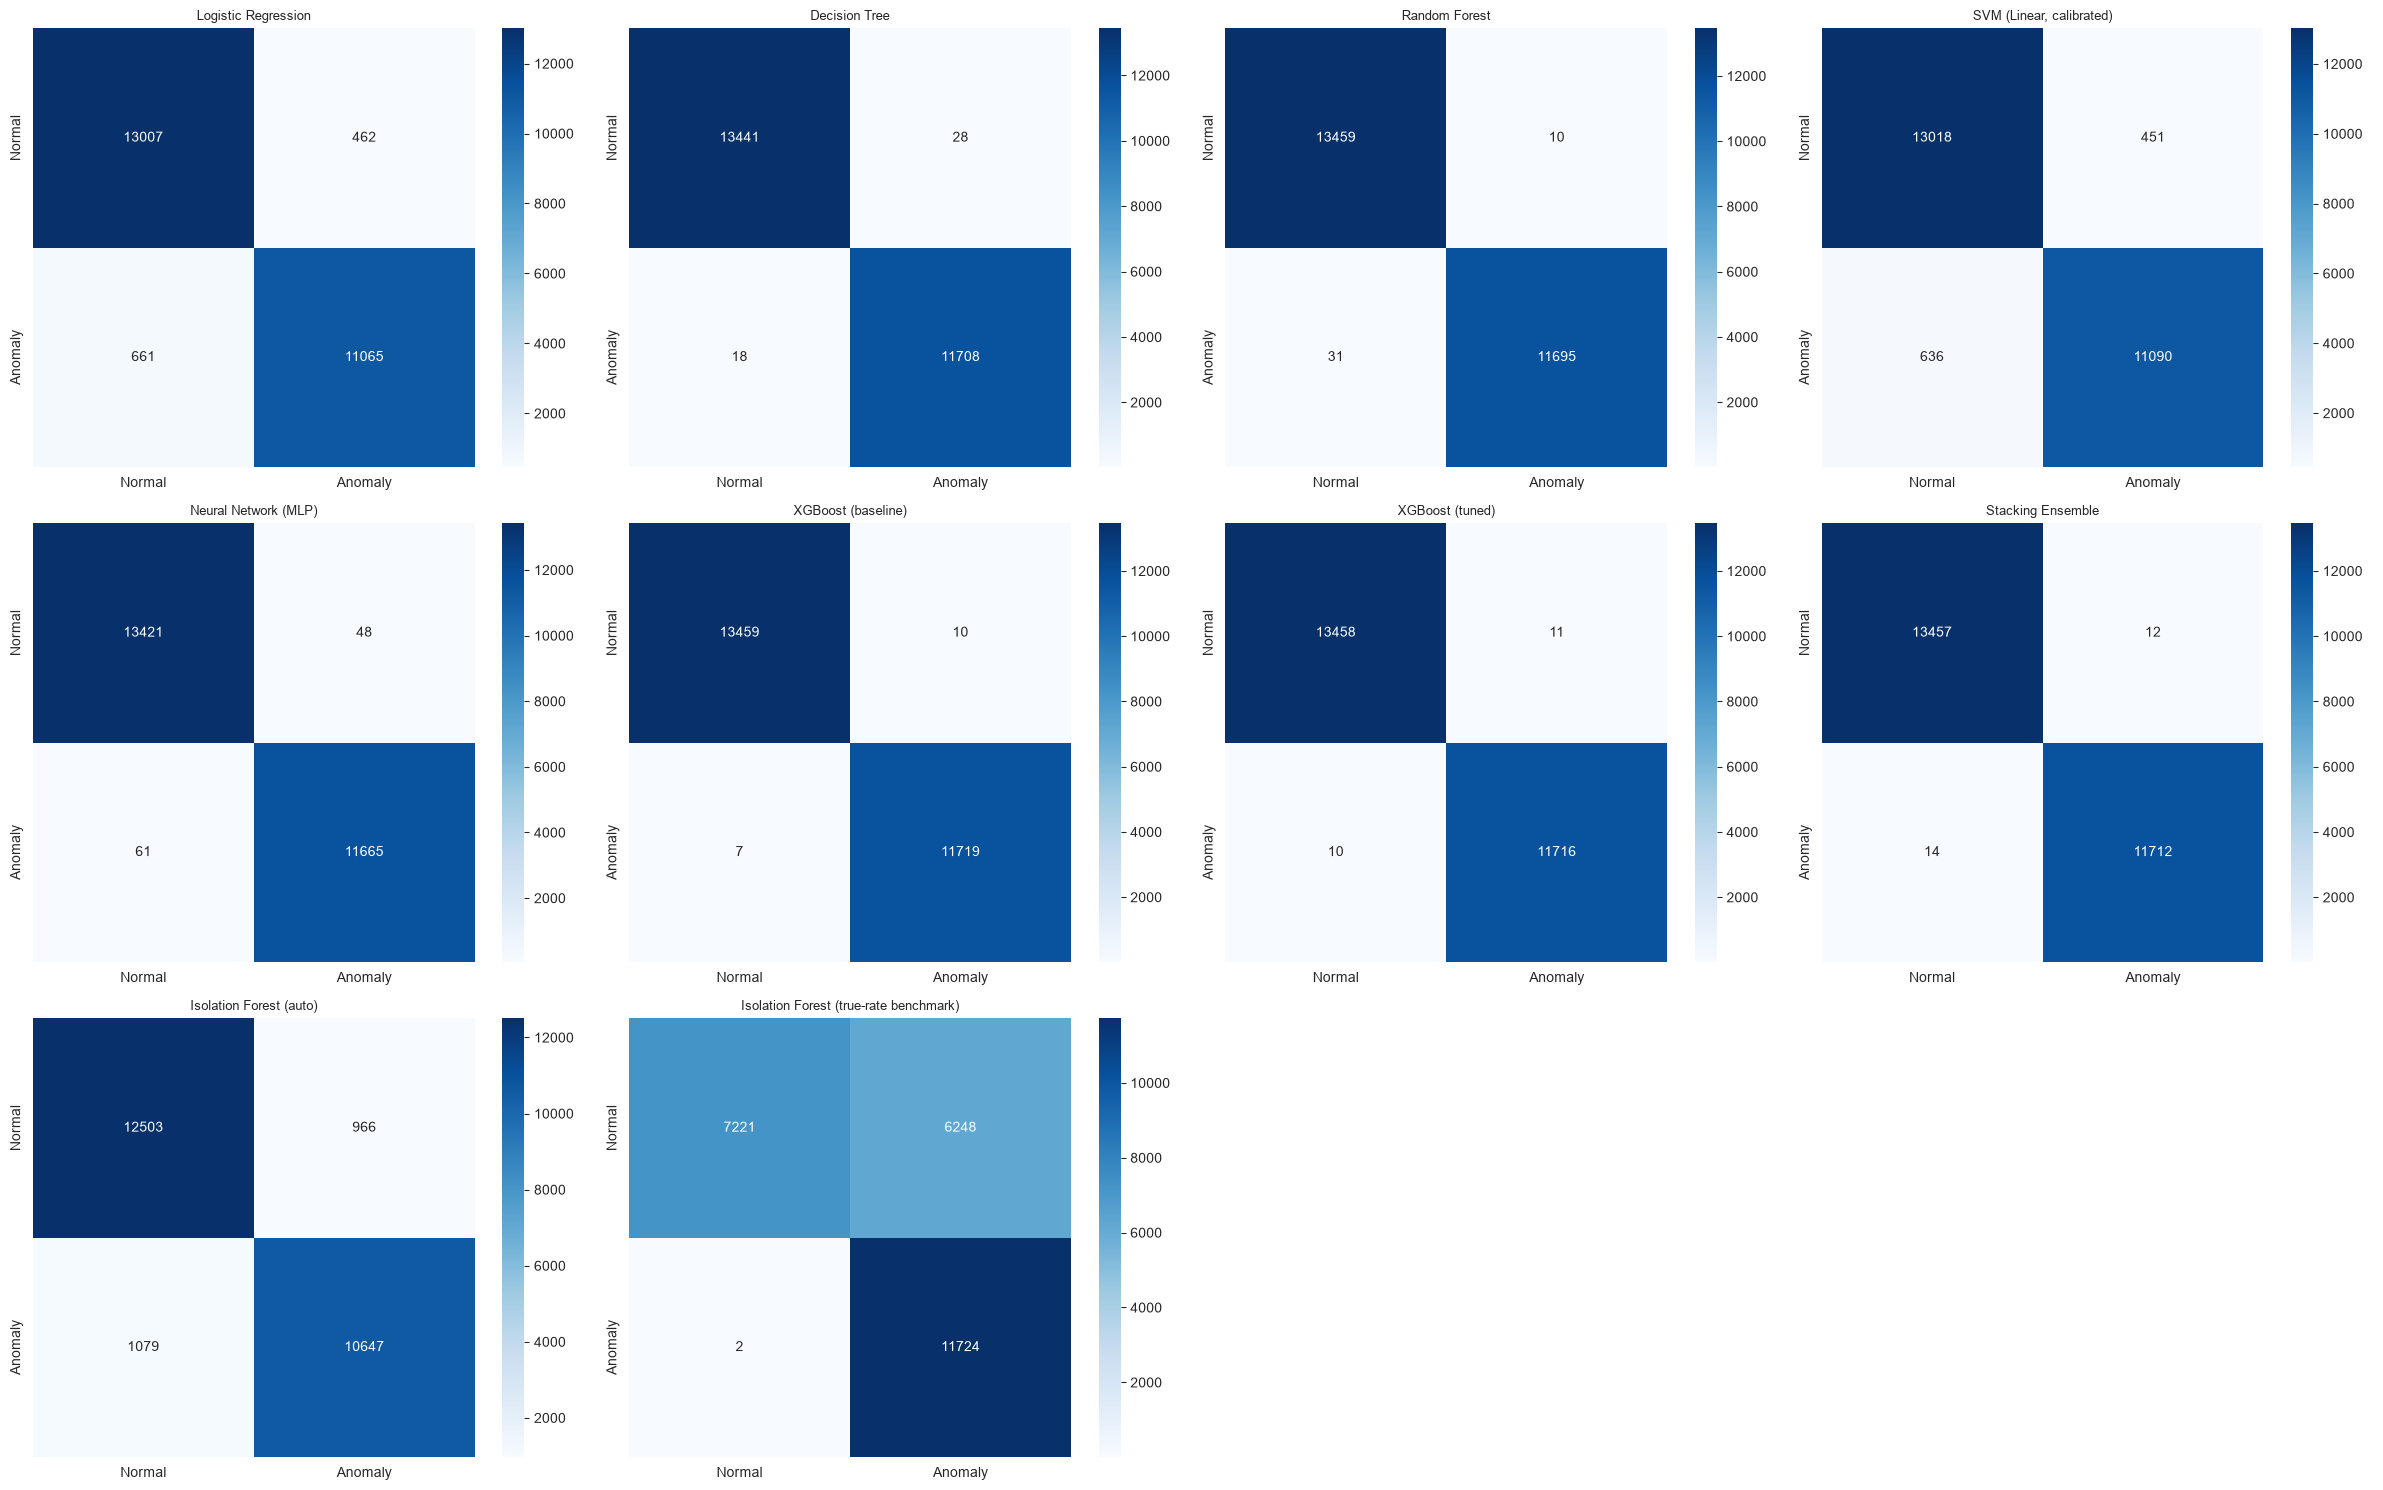

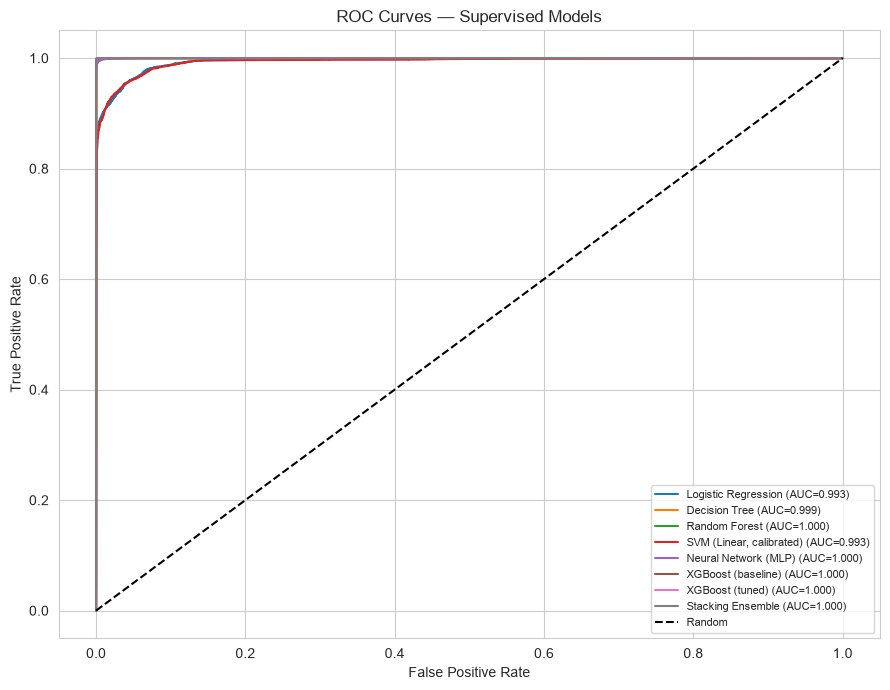


                                      Model  Accuracy     F1  Precision  Recall  ROC-AUC
                       Logistic Regression    0.9554 0.9517     0.9599  0.9436   0.9934
                             Decision Tree    0.9982 0.9980     0.9976  0.9985   0.9993
                             Random Forest    0.9984 0.9983     0.9991  0.9974   1.0000
                  SVM (Linear, calibrated)    0.9569 0.9533     0.9609  0.9458   0.9931
                      Neural Network (MLP)    0.9957 0.9953     0.9959  0.9948   0.9998
                        XGBoost (baseline)    0.9993 0.9993     0.9991  0.9994   1.0000
                           XGBoost (tuned)    0.9992 0.9991     0.9991  0.9991   1.0000
                         Stacking Ensemble    0.9990 0.9989     0.9990  0.9988   1.0000
                   Isolation Forest (auto)    0.9188 0.9124     0.9168  0.9080      NaN
    Isolation Forest (true-rate benchmark)    0.7519 0.7895     0.6523  0.9998      NaN
XGBoost (tuned, recall-favorin

In [27]:
from sklearn.metrics import (
    confusion_matrix, roc_curve, accuracy_score,
)

def summarize_binary(state):
    """Step 6 -- compare all binary models, save confusion matrices and ROC
    curves. Inlined from trainer/binary_summary.py::summarize_binary.

    Writes to state: results_df
    Returns: dict with 'best_binary_model' key.
    """
    print("\n" + "=" * 70)
    print("MODEL COMPARISON SUMMARY (binary is_anomaly)")
    print("=" * 70)

    def get_metrics(y_true, y_pred, name, proba=None):
        p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
        auc = round(float(roc_auc_score(y_true, proba)), 4) if proba is not None else None
        row = {"Model": name,
               "Accuracy":  round(float(accuracy_score(y_true, y_pred)), 4),
               "F1":        round(float(f), 4),
               "Precision": round(float(p), 4),
               "Recall":    round(float(r), 4)}
        if auc is not None:
            row["ROC-AUC"] = auc
        return row

    rows = []
    for name, preds in state.binary_preds.items():
        proba = state.binary_probas.get(name)
        rows.append(get_metrics(state.y_test, preds, name, proba))
    # Recall-tuned variant -- same probabilities as XGBoost (tuned), different threshold
    rows.append(get_metrics(state.y_test, state.y_pred_recall_tuned,
                            "XGBoost (tuned, recall-favoring threshold)",
                            state.binary_probas.get("XGBoost (tuned)")))
    state.results_df = pd.DataFrame(rows)
    print(state.results_df.to_string(index=False))

    # Confusion matrices
    n_models = len(state.binary_preds)
    n_cols   = min(n_models, 4)
    n_rows   = int(np.ceil(n_models / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    axes = np.array(axes).flatten()
    for ax, (name, preds) in zip(axes, state.binary_preds.items()):
        cm = confusion_matrix(state.y_test, preds)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                    xticklabels=["Normal", "Anomaly"],
                    yticklabels=["Normal", "Anomaly"])
        ax.set_title(name, fontsize=9)
    for j in range(n_models, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    state.savefig("confusion_matrices_comparison.png")

    # ROC curves
    plt.figure(figsize=(9, 7))
    for name, proba in state.binary_probas.items():
        if proba is None:
            continue
        fpr, tpr, _ = roc_curve(state.y_test, proba)
        auc = roc_auc_score(state.y_test, proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves — Supervised Models")
    plt.legend(fontsize=8)
    plt.tight_layout()
    state.savefig("roc_curves.png")

    best_name = state.results_df.loc[state.results_df["F1"].idxmax(), "Model"]

    # Save comparison as JSON so results can be displayed / re-loaded later.
    # NOTE: state.results_df is built from rows with heterogeneous keys
    # (e.g. Isolation Forest rows have no "ROC-AUC" since they expose no
    # probability scores). pandas.DataFrame fills those gaps with NaN,
    # and NaN is NOT valid JSON -- json.dump() happily writes a bare `NaN`
    # token, which would make a browser's JSON.parse() throw. Drop NaN
    # entries instead of serializing them, same as columns that were never
    # populated for a given model.
    comp = {
        "best":   best_name,
        "models": [
            {k: (round(v, 4) if isinstance(v, float) else v)
             for k, v in row.items()
             if v is not None and not (isinstance(v, float) and np.isnan(v))}
            for row in state.results_df.to_dict(orient="records")
        ],
    }
    comp_path = os.path.join(state.model_dir, "binary_comparison.json")
    with open(comp_path, "w") as _f:
        json.dump(comp, _f, indent=2)
    print(f"  Saved: binary_comparison.json")

    return {"best_binary_model": best_name}

binary_info = summarize_binary(state)
show_plot("confusion_matrices_comparison.png")
show_plot("roc_curves.png")
print("\n", state.results_df.to_string(index=False))


## 8. ML Modeling — Multi-class Classification (attack type) — `train_multiclass()` (inlined below, was `trainer.multiclass.train_multiclass`)

Beyond "is this anomalous," identifying **which** attack type it is. Attack types with fewer than 20
training samples are grouped into a single `other_rare` bucket (the exact rule the original
`trainer/multiclass.py` uses — not a quantile heuristic). Trains Logistic Regression, Decision Tree,
Random Forest, XGBoost.



######################################################################
# SUPERVISED MODELS — MULTI-CLASS (attack type)
######################################################################
Grouped 10 rare attack types → 'other_rare'. Final class count: 14

Logistic Regression: Acc=0.9884  Macro F1=0.9170  Macro AUC=0.9991

Decision Tree: Acc=0.9942  Macro F1=0.9019  Macro AUC=0.9721

Random Forest: Acc=0.9986  Macro F1=0.9718  Macro AUC=0.9999

XGBoost: Acc=0.9992  Macro F1=0.9757  Macro AUC=0.9998

--- Multi-class comparison ---
              Model  Accuracy  Macro F1  Macro AUC (OVR)
Logistic Regression  0.988410  0.916978         0.999061
      Decision Tree  0.994166  0.901887         0.972144
      Random Forest  0.998611  0.971835         0.999913
            XGBoost  0.999246  0.975725         0.999841
  Saved: multiclass_comparison.json

Detailed report — XGBoost
                 precision    recall  f1-score   support

           back       1.00      1.00      1.00       196

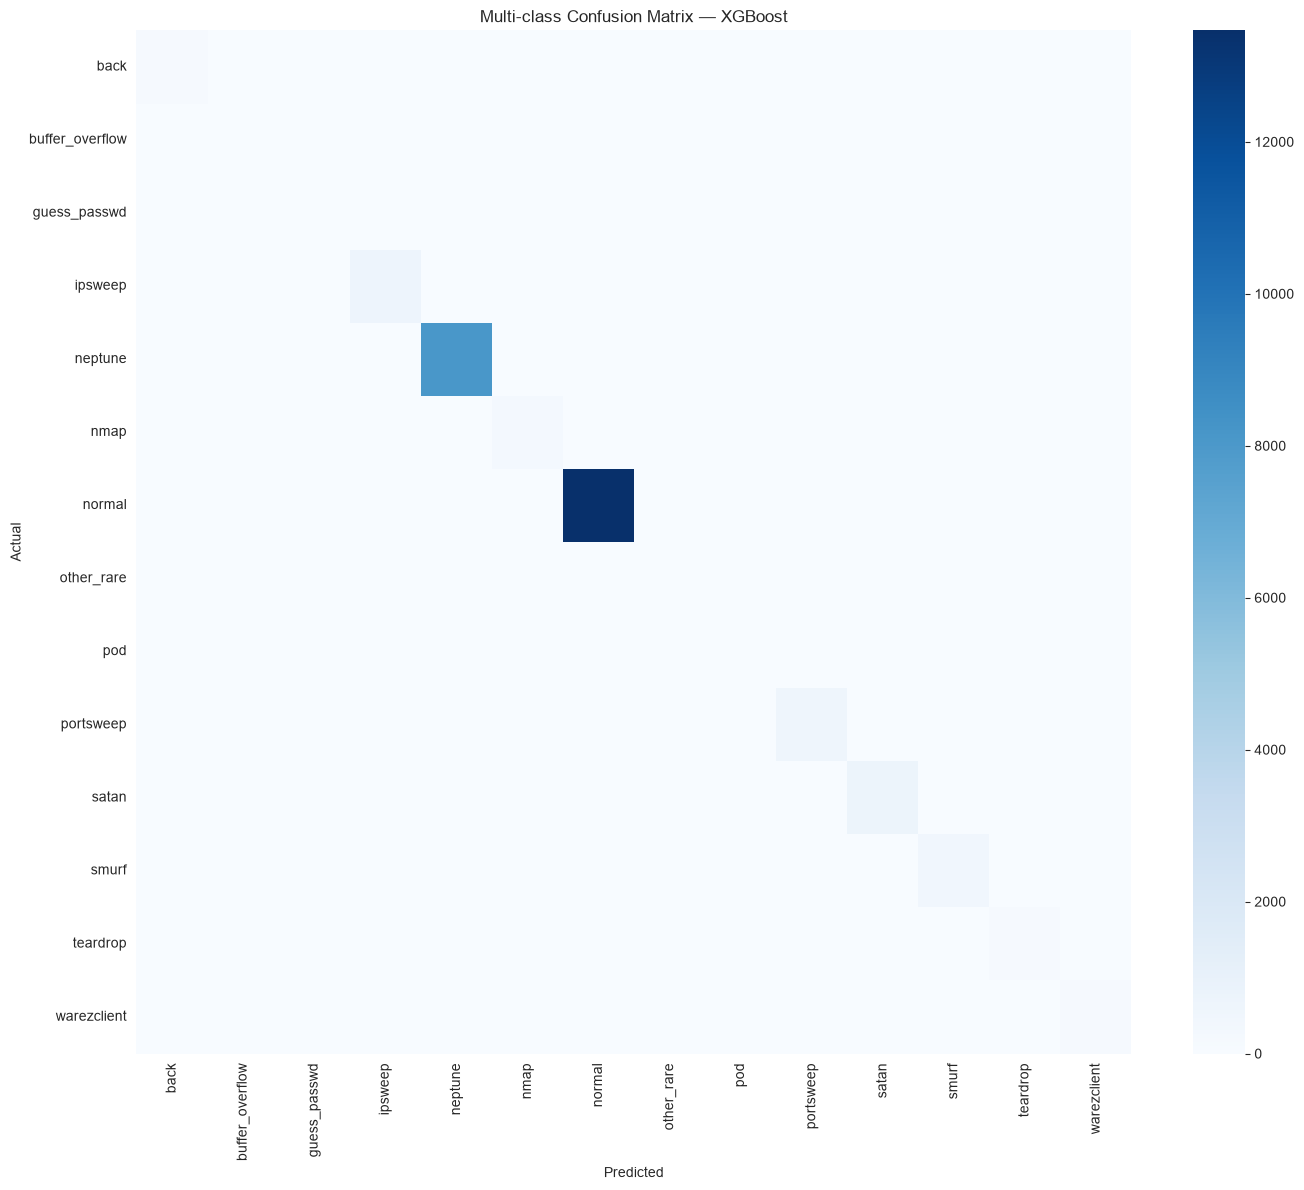

In [28]:
def train_multiclass(state):
    """Step 7 -- multi-class attack-type classification.
    Inlined from trainer/multiclass.py::train_multiclass.

    Models: Logistic Regression, Decision Tree, Random Forest, XGBoost.
    Rare attack types (< 20 training samples) are grouped into 'other_rare'.

    Writes to state: le_attack, xgb_multi, best_multi_name
    """
    print("\n" + "#" * 70)
    print("# SUPERVISED MODELS — MULTI-CLASS (attack type)")
    print("#" * 70)

    MIN_COUNT = 20
    rare   = state.attack_train.value_counts()[lambda s: s < MIN_COUNT].index
    atk_tr = state.attack_train.where(~state.attack_train.isin(rare), "other_rare")
    atk_te = state.attack_test.where(~state.attack_test.isin(rare),  "other_rare")
    print(f"Grouped {len(rare)} rare attack types → 'other_rare'. "
          f"Final class count: {atk_tr.nunique()}")

    state.le_attack = LabelEncoder()
    y_tr_m = state.le_attack.fit_transform(atk_tr)
    known  = set(state.le_attack.classes_)
    atk_te_safe = atk_te.where(atk_te.isin(known), "other_rare")
    y_te_m = state.le_attack.transform(atk_te_safe)

    models_cfg = {
        "Logistic Regression": (
            LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
            state.X_train_scaled, state.X_test_scaled,
        ),
        "Decision Tree": (
            DecisionTreeClassifier(max_depth=15, min_samples_leaf=5,
                                    random_state=RANDOM_STATE),
            state.X_train, state.X_test,
        ),
        "Random Forest": (
            RandomForestClassifier(n_estimators=200, max_depth=20,
                                    random_state=RANDOM_STATE, n_jobs=-1),
            state.X_train, state.X_test,
        ),
        "XGBoost": (
            xgb.XGBClassifier(
                n_estimators=300, max_depth=8, learning_rate=0.1,
                objective="multi:softprob", eval_metric="mlogloss",
                random_state=RANDOM_STATE, n_jobs=-1,
            ),
            state.X_train, state.X_test,
        ),
    }

    multi_results = []
    preds_store   = {}
    for name, (model, X_tr, X_te) in models_cfg.items():
        model.fit(X_tr, y_tr_m)
        preds = model.predict(X_te)
        preds_store[name] = (model, preds)
        acc = accuracy_score(y_te_m, preds)
        _, _, f1_macro, _ = precision_recall_fscore_support(
            y_te_m, preds, average="macro", zero_division=0
        )
        auc_ovr = np.nan
        if hasattr(model, "predict_proba"):
            try:
                auc_ovr = roc_auc_score(
                    y_te_m, model.predict_proba(X_te),
                    multi_class="ovr", average="macro",
                )
            except Exception as exc:
                print(f"  (ROC-AUC unavailable for {name}: {exc})")
        multi_results.append({"Model": name, "Accuracy": acc,
                               "Macro F1": f1_macro, "Macro AUC (OVR)": auc_ovr})
        print(f"\n{name}: Acc={acc:.4f}  Macro F1={f1_macro:.4f}  Macro AUC={auc_ovr:.4f}")

    multi_df = pd.DataFrame(multi_results)
    print("\n--- Multi-class comparison ---")
    print(multi_df.to_string(index=False))

    state.best_multi_name = multi_df.loc[multi_df["Macro F1"].idxmax(), "Model"]

    # Save comparison JSON
    multi_comp = {
        "best": state.best_multi_name,
        "models": [
            {k: (round(v, 4) if isinstance(v, float) and v == v else (None if v != v else v))
             for k, v in row.items()}
            for row in multi_df.to_dict(orient="records")
        ],
    }
    multi_comp_path = os.path.join(state.model_dir, "multiclass_comparison.json")
    with open(multi_comp_path, "w") as _f:
        json.dump(multi_comp, _f, indent=2)
    print(f"  Saved: multiclass_comparison.json")

    best_model, best_preds = preds_store[state.best_multi_name]
    print(f"\nDetailed report — {state.best_multi_name}")
    print(classification_report(y_te_m, best_preds,
                                 labels=range(len(state.le_attack.classes_)),
                                 target_names=state.le_attack.classes_, zero_division=0))

    cm_m = confusion_matrix(y_te_m, best_preds)
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm_m, annot=False, cmap="Blues",
                xticklabels=state.le_attack.classes_,
                yticklabels=state.le_attack.classes_)
    plt.title(f"Multi-class Confusion Matrix — {state.best_multi_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=90)
    plt.tight_layout()
    state.savefig("multiclass_confusion_matrix.png")

    state.xgb_multi = preds_store["XGBoost"][0]

train_multiclass(state)
show_plot("multiclass_confusion_matrix.png")


**Result:** macro F1 across the final classes is meaningfully lower than binary F1 — expected: correctly
naming *which* of many attack families a connection belongs to is a strictly harder problem than the
binary is-it-anomalous question, especially for the rarer classes bundled into `other_rare`.


## 9. ML Modeling — Unsupervised Methods — `train_unsupervised()` (inlined below, was `trainer.unsupervised.train_unsupervised`)

Runs clustering (K-Means, DBSCAN, Hierarchical/Agglomerative — kept together with `train_unsupervised`)
and, via the `run_pca_projection` / `run_tsne_projection` / `run_pca_reconstruction` helper functions
(inlined in the same cell below, reproducing the original **separate** `dimensionality_reduction.py`
module — kept separate there since dimensionality reduction is a different technique from clustering, see
that module's own docstring): PCA 2D projection (visualization), t-SNE (visualization), and **PCA
Reconstruction Error** — the one unsupervised method that's actually served at inference, fit on
normal-only traffic with reconstruction error as the anomaly score.


In [29]:
from sklearn.preprocessing import QuantileTransformer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage as scipy_linkage
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


def run_pca_projection(state, X_samp, y_samp):
    """2D PCA scatter plot, colored by true label. Visualization only.
    Inlined from dimensionality_reduction.py::run_pca_projection."""
    print("\n" + "=" * 70)
    print("DIMENSIONALITY REDUCTION: PCA Projection (2D, visualization only)")
    print("=" * 70)
    pca2  = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca2.fit_transform(X_samp)
    print(f"PCA explained variance (2 components): "
          f"{pca2.explained_variance_ratio_.sum():.4f}")

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_samp, cmap="coolwarm", s=5, alpha=0.5)
    plt.title("PCA Projection (2D) — colored by true is_anomaly")
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.colorbar(label="is_anomaly")
    plt.tight_layout()
    state.savefig("pca_projection.png")
    return X_pca


def run_tsne_projection(state, X_samp, y_samp, km_labels, hier_labels):
    """2D t-SNE scatter plots (visualization only), one panel each for the
    true label and the two clustering results computed upstream (K-Means,
    Hierarchical) -- lets you eyeball how well each clustering aligns with
    the non-linear t-SNE layout.
    Inlined from dimensionality_reduction.py::run_tsne_projection."""
    print("\n" + "=" * 70)
    print("DIMENSIONALITY REDUCTION: t-SNE Projection (2D, may take a minute)")
    print("=" * 70)
    tsne   = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, init="pca")
    X_tsne = tsne.fit_transform(X_samp)

    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_samp,      cmap="coolwarm", s=5, alpha=0.5)
    axes[0].set_title("t-SNE — true is_anomaly")
    axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=km_labels,   cmap="viridis",  s=5, alpha=0.5)
    axes[1].set_title("t-SNE — K-Means cluster")
    axes[2].scatter(X_tsne[:, 0], X_tsne[:, 1], c=hier_labels, cmap="plasma",   s=5, alpha=0.5)
    axes[2].set_title("t-SNE — Hierarchical cluster")
    plt.tight_layout()
    state.savefig("tsne_comparison.png")
    return X_tsne


def run_pca_reconstruction(state):
    """Fit PCA on normal-only traffic and use reconstruction error as an
    unsupervised anomaly score. Unlike the two functions above, this
    result IS used at inference time and IS saved as an artifact
    (pca_reconstruction_model.pkl).
    Inlined from dimensionality_reduction.py::run_pca_reconstruction.

    Writes to state: pca_recon, recon_auc, recon_threshold
    """
    print("\n" + "=" * 70)
    print("DIMENSIONALITY REDUCTION: PCA Reconstruction Error (unsupervised anomaly score)")
    print("=" * 70)
    X_norm_sc = state.scaler.transform(state.X_train[state.y_train == 0])
    n_comp    = 15
    state.pca_recon = PCA(n_components=n_comp, random_state=RANDOM_STATE)
    state.pca_recon.fit(X_norm_sc)
    print(f"Explained variance ({n_comp} components): "
          f"{state.pca_recon.explained_variance_ratio_.sum():.4f}")

    X_recon   = state.pca_recon.inverse_transform(
        state.pca_recon.transform(state.X_test_scaled)
    )
    recon_err = np.mean((state.X_test_scaled - X_recon) ** 2, axis=1)
    state.recon_auc = roc_auc_score(state.y_test, recon_err)
    print(f"ROC-AUC (PCA reconstruction): {state.recon_auc:.4f}")

    X_nr     = state.pca_recon.inverse_transform(state.pca_recon.transform(X_norm_sc))
    norm_err = np.mean((X_norm_sc - X_nr) ** 2, axis=1)
    state.recon_threshold = float(np.percentile(norm_err, 95))
    y_pred_recon = (recon_err > state.recon_threshold).astype(int)
    print(f"\nAt 95th-pct normal threshold ({state.recon_threshold:.4f}):")
    print(classification_report(state.y_test, y_pred_recon, target_names=["Normal", "Anomaly"]))

    plt.figure(figsize=(8, 5))
    plt.hist(recon_err[state.y_test == 0], bins=50, alpha=0.6, label="Normal",  density=True)
    plt.hist(recon_err[state.y_test == 1], bins=50, alpha=0.6, label="Anomaly", density=True)
    plt.axvline(state.recon_threshold, color="black", linestyle="--",
                label="95th pct normal threshold")
    plt.xlabel("PCA Reconstruction Error"); plt.ylabel("Density")
    plt.title("PCA Reconstruction Error — Normal vs Anomaly")
    plt.legend()
    plt.xlim(0, np.percentile(recon_err, 99))
    plt.tight_layout()
    state.savefig("pca_reconstruction_error.png")


def train_unsupervised(state):
    """Step 8 -- unsupervised anomaly detection methods.
    Inlined from trainer/unsupervised.py::train_unsupervised.

    CLUSTERING (K-Means, DBSCAN, Hierarchical/Agglomerative) lives in this
    function. DIMENSIONALITY REDUCTION (PCA projection, t-SNE, PCA
    reconstruction error) lives in the three functions above -- kept
    logically separate (same as the original dimensionality_reduction.py
    module) since clustering groups points together while dimensionality
    reduction compresses the feature space instead -- they answer different
    questions.

    Writes to state: pca_recon, recon_auc, recon_threshold (via
    run_pca_reconstruction above).
    """
    print("\n" + "#" * 70)
    print("# UNSUPERVISED METHODS")
    print("#" * 70)

    print("\nDiagnostic — columns with near-zero IQR:")
    q1 = state.X_train.astype(float).quantile(0.25)
    q3 = state.X_train.astype(float).quantile(0.75)
    zero_iqr = ((q3 - q1) < 1e-9).index[(q3 - q1) < 1e-9].tolist()
    print(f"  {zero_iqr}")

    qt       = QuantileTransformer(output_distribution="uniform",
                                    n_quantiles=1000, random_state=RANDOM_STATE)
    X_robust = qt.fit_transform(state.X_train.astype(float))

    SAMPLE_SIZE = 10_000
    rng = np.random.RandomState(RANDOM_STATE)
    idx = rng.choice(state.X_train.shape[0],
                      size=min(SAMPLE_SIZE, state.X_train.shape[0]), replace=False)
    X_samp   = X_robust[idx]
    y_samp   = state.y_train.values[idx]
    X_samp_s = state.X_train_scaled[idx]

    # PCA 2D projection -- dimensionality reduction, not clustering.
    run_pca_projection(state, X_samp, y_samp)

    # K-Means
    print("\n--- K-Means: effect of QuantileTransformer ---")
    km_before = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
    lb_before = km_before.fit_predict(X_samp_s)
    match_b   = max((lb_before == y_samp).mean(), (lb_before == (1 - y_samp)).mean())
    print(f"BEFORE (StandardScaler):     Sil={silhouette_score(X_samp_s, lb_before):.4f}  "
          f"alignment={match_b:.4f}")

    km        = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
    km_labels = km.fit_predict(X_samp)
    match_a   = max((km_labels == y_samp).mean(), (km_labels == (1 - y_samp)).mean())
    km_sil    = float(silhouette_score(X_samp, km_labels))
    km_db     = float(davies_bouldin_score(X_samp, km_labels))
    print(f"AFTER  (QuantileTransformer): Sil={km_sil:.4f}  DB={km_db:.4f}  alignment={match_a:.4f}")

    # DBSCAN with auto eps
    MIN_SAMPLES = 10
    nn = NearestNeighbors(n_neighbors=MIN_SAMPLES)
    nn.fit(X_samp)
    k_dist, _ = nn.kneighbors(X_samp)
    auto_eps  = float(np.percentile(np.sort(k_dist[:, -1]), 90))
    print(f"\nDBSCAN auto eps (90th pct): {auto_eps:.4f}")
    plt.figure(figsize=(8, 5))
    plt.plot(np.sort(k_dist[:, -1]))
    plt.axhline(auto_eps, color="red", linestyle="--", label=f"eps={auto_eps:.4f}")
    plt.xlabel("Points sorted by k-distance")
    plt.ylabel(f"{MIN_SAMPLES}-NN distance")
    plt.title("DBSCAN k-distance plot")
    plt.legend()
    plt.tight_layout()
    state.savefig("dbscan_kdistance.png")

    dbscan    = DBSCAN(eps=auto_eps, min_samples=MIN_SAMPLES, n_jobs=-1)
    db_labels = dbscan.fit_predict(X_samp)
    n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    n_noise    = int((db_labels == -1).sum())
    print(f"DBSCAN — clusters: {n_clusters}, noise: {n_noise}")
    dbscan_sil = None
    dbscan_db  = None
    if n_clusters >= 2:
        nm = db_labels != -1
        dbscan_sil = float(silhouette_score(X_samp[nm], db_labels[nm]))
        dbscan_db  = float(davies_bouldin_score(X_samp[nm], db_labels[nm]))
        print(f"DBSCAN Sil={dbscan_sil:.4f}  DB={dbscan_db:.4f}")

    # Hierarchical clustering
    print("\nRunning Hierarchical (Agglomerative) Clustering…")
    hier        = AgglomerativeClustering(n_clusters=2, linkage="ward")
    hier_labels = hier.fit_predict(X_samp)
    match_h     = max((hier_labels == y_samp).mean(), (hier_labels == (1 - y_samp)).mean())
    hier_sil    = float(silhouette_score(X_samp, hier_labels))
    hier_db     = float(davies_bouldin_score(X_samp, hier_labels))
    print(f"Hierarchical: Sil={hier_sil:.4f}  DB={hier_db:.4f}  alignment={match_h:.4f}")

    dendro_idx = rng.choice(X_samp.shape[0], size=300, replace=False)
    Z = scipy_linkage(X_samp[dendro_idx], method="ward")
    plt.figure(figsize=(14, 6))
    dendrogram(Z, no_labels=True)
    plt.title("Hierarchical Clustering Dendrogram (300-point subsample)")
    plt.xlabel("Samples"); plt.ylabel("Distance")
    plt.tight_layout()
    state.savefig("dendrogram.png")

    # t-SNE -- dimensionality reduction, not clustering. Reuses the cluster
    # labels computed above purely to color the visualization.
    run_tsne_projection(state, X_samp, y_samp, km_labels, hier_labels)

    # PCA Reconstruction Error -- dimensionality reduction used as an
    # unsupervised anomaly score; this IS served at inference.
    run_pca_reconstruction(state)

    # ------------------------------------------------------------------
    # Save unsupervised comparison JSON.
    # Metrics: Silhouette (higher better, -1..1), Davies-Bouldin (lower better, >=0)
    # For PCA: ROC-AUC is the quality metric.
    # ------------------------------------------------------------------
    unsu_rows = [
        {
            "Model":          "K-Means (QuantileTransformer)",
            "Silhouette":     round(km_sil, 4),
            "Davies-Bouldin": round(km_db, 4),
            "Note":           f"alignment={match_a:.3f} ({len(y_samp):,}-pt sample)",
        },
        {
            "Model":          "Hierarchical (Ward linkage)",
            "Silhouette":     round(hier_sil, 4),
            "Davies-Bouldin": round(hier_db, 4),
            "Note":           f"alignment={match_h:.3f} ({len(y_samp):,}-pt sample)",
        },
        {
            "Model":          "DBSCAN (auto eps)",
            "Silhouette":     round(dbscan_sil, 4) if dbscan_sil is not None else "—",
            "Davies-Bouldin": round(dbscan_db, 4)  if dbscan_db  is not None else "—",
            "Note":           f"{n_clusters} cluster(s), {n_noise} noise pts, eps={auto_eps:.4f}",
        },
        {
            "Model":          "PCA Reconstruction Error",
            "Silhouette":     "—",
            "Davies-Bouldin": "—",
            "ROC-AUC":        round(state.recon_auc, 4),
            "Note":           (f"Dimensionality reduction (15 PCA components) — reconstructs each "
                               f"connection and flags it anomalous above threshold={state.recon_threshold:.4f}"),
        },
    ]
    # Best = highest Silhouette among methods that have one
    sil_rows   = [r for r in unsu_rows if isinstance(r.get("Silhouette"), float)]
    best_unsup = max(sil_rows, key=lambda r: r["Silhouette"])["Model"] if sil_rows else "PCA Reconstruction Error"
    unsu_comp  = {"best": best_unsup, "models": unsu_rows}
    comp_path  = os.path.join(state.model_dir, "unsupervised_comparison.json")
    with open(comp_path, "w") as _f:
        json.dump(unsu_comp, _f, indent=2)
    print(f"  Saved: unsupervised_comparison.json")

train_unsupervised(state)



######################################################################
# UNSUPERVISED METHODS
######################################################################

Diagnostic — columns with near-zero IQR:
  ['duration', 'land', 'wrongfragment', 'urgent', 'hot', 'numfailedlogins', 'numcompromised', 'rootshell', 'suattempted', 'numroot', 'numfilecreations', 'numshells', 'numaccessfiles', 'ishostlogin', 'isguestlogin', 'rerrorrate', 'srvrerrorrate', 'srvdiffhostrate', 'dsthostrerrorrate', 'dsthostsrvrerrorrate', 'is_icmp', 'protocoltype_tcp', 'protocoltype_udp', 'flag_REJ', 'flag_RSTO', 'flag_RSTOS0', 'flag_RSTR', 'flag_S1', 'flag_S2', 'flag_S3', 'flag_SH']

DIMENSIONALITY REDUCTION: PCA Projection (2D, visualization only)
PCA explained variance (2 components): 0.6371

--- K-Means: effect of QuantileTransformer ---
BEFORE (StandardScaler):     Sil=0.9795  alignment=0.5404
AFTER  (QuantileTransformer): Sil=0.4438  DB=0.9684  alignment=0.8844

DBSCAN auto eps (90th pct): 0.8236
DBSCAN — 

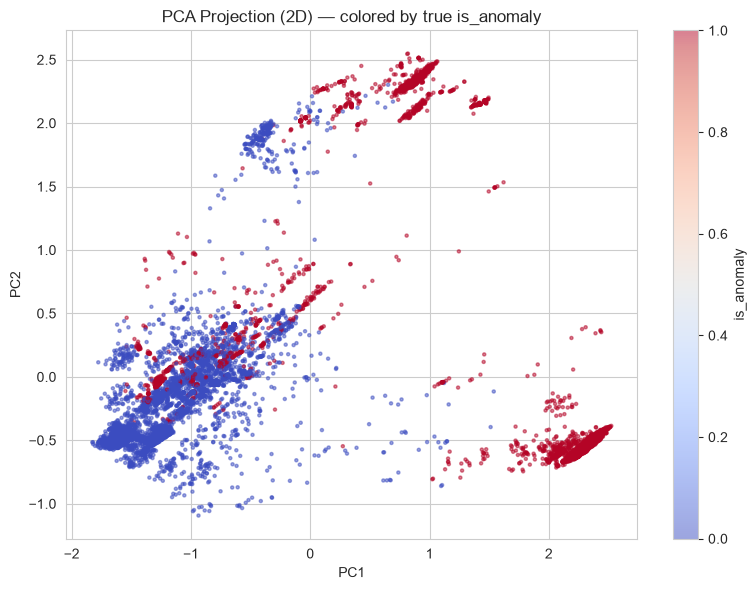

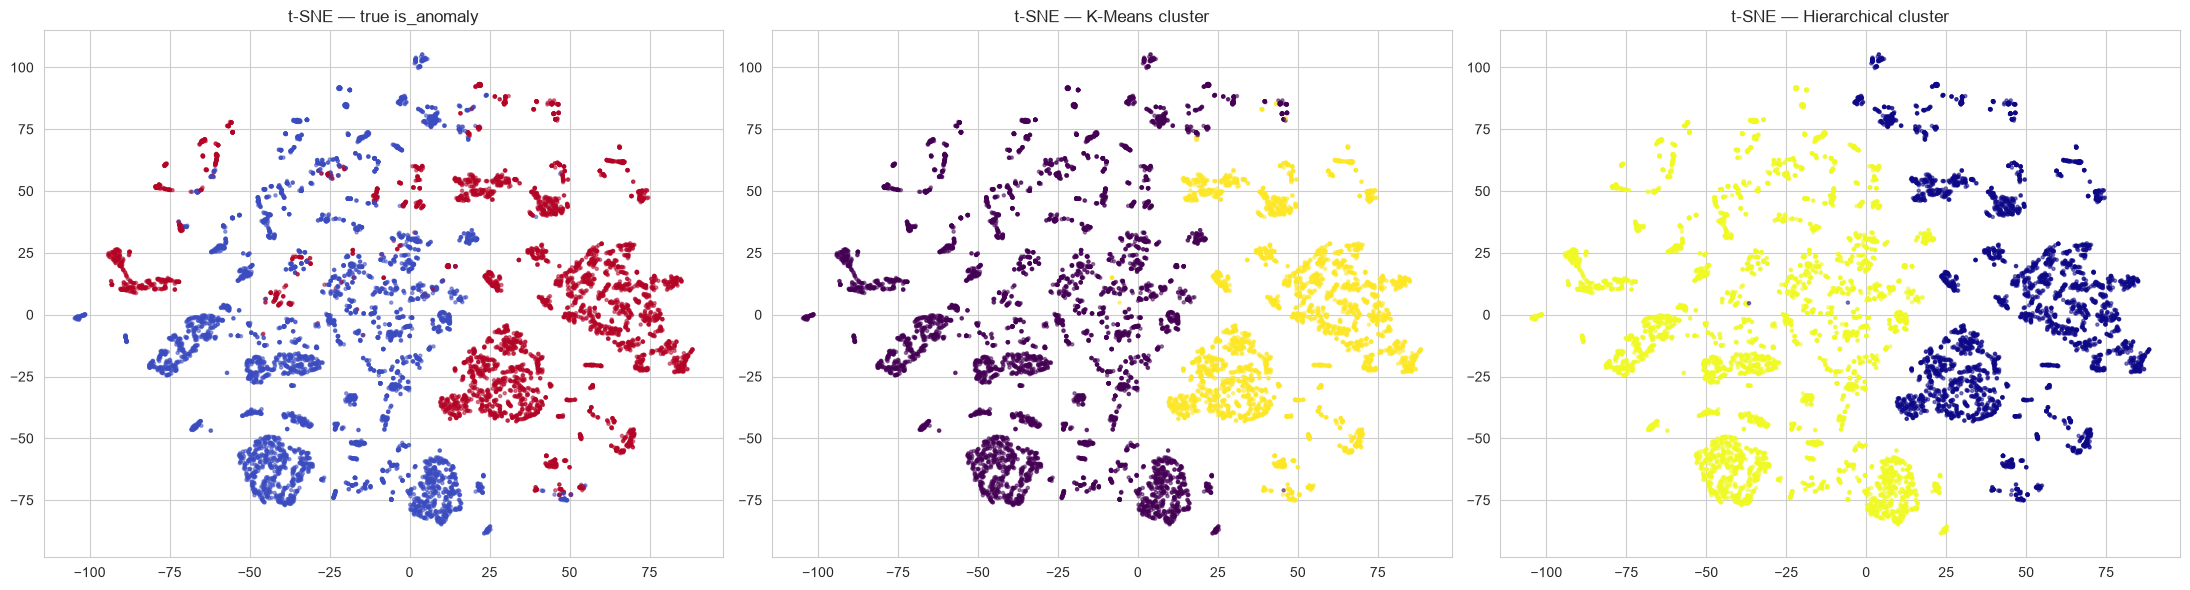

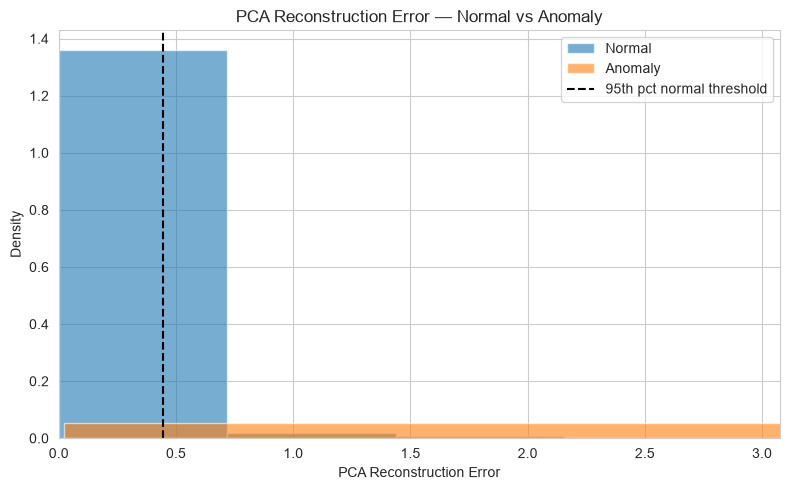

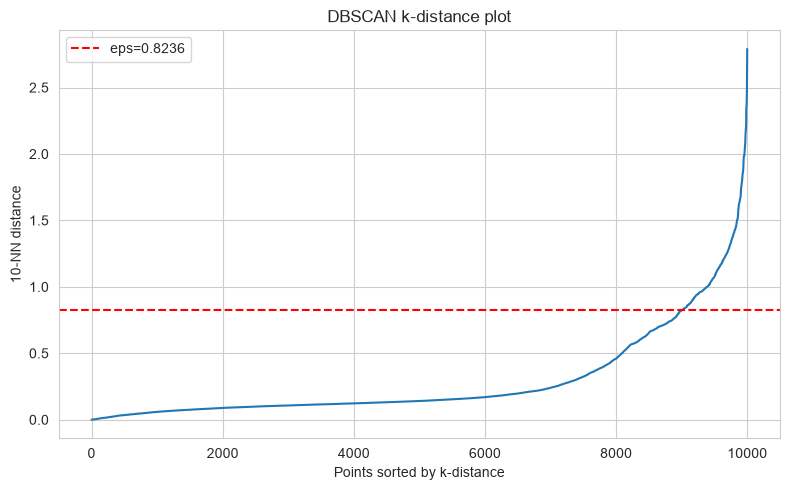

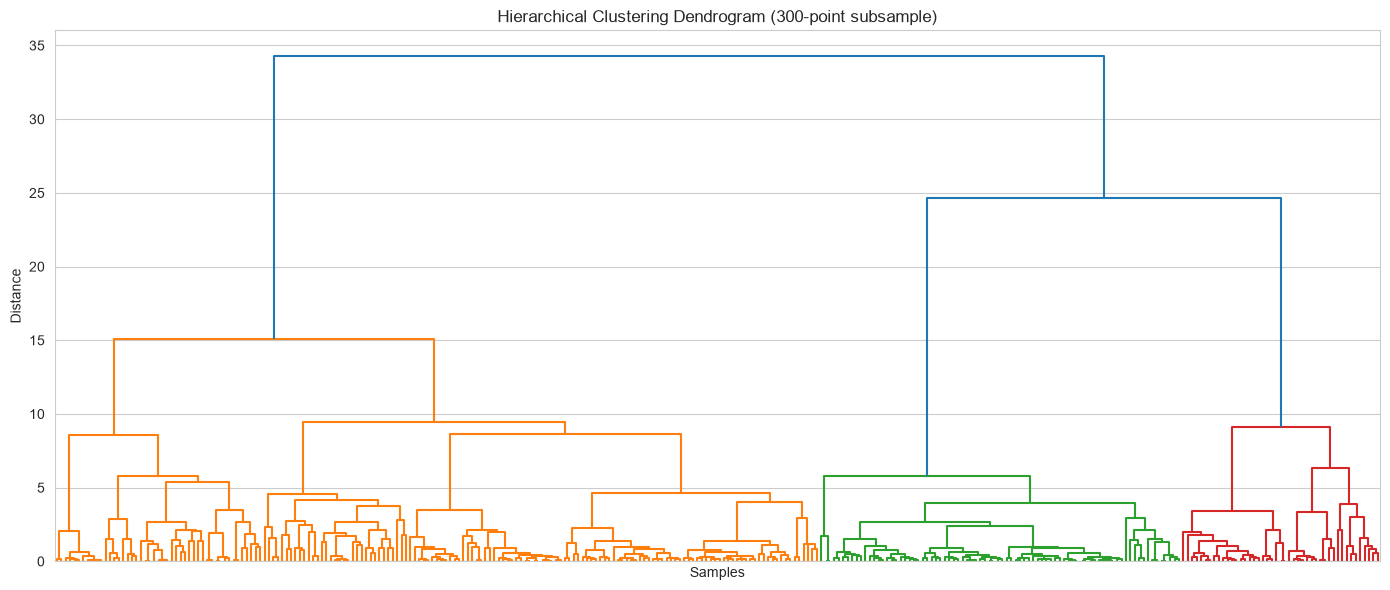

In [30]:
show_plot("pca_projection.png")
show_plot("tsne_comparison.png")
show_plot("pca_reconstruction_error.png")
show_plot("dbscan_kdistance.png")
show_plot("dendrogram.png")


**Result:** K-Means edges out the other clustering methods on silhouette score with strong alignment to
the true binary label despite using zero labels. PCA Reconstruction Error achieves the strongest
"practically useful" result of the unsupervised methods — see `state.recon_auc` above — specifically
because it's the one that ships to production as an independent safety net for attack patterns
structurally unlike any of the labeled families the supervised models were trained on.

### 9.1 Save artifacts & build summary — `save_artifacts()` / `build_summary()` (inlined below, was `trainer.artifacts.save_artifacts` / `build_summary`)


In [31]:
import joblib

def save_artifacts(state):
    """Step 9 -- persist all trained artifacts to disk.
    Inlined from trainer/artifacts.py::save_artifacts. Writes into
    MODEL_DIR (standalone_artifacts/), not the real backend model_artifacts/."""
    print("\n" + "=" * 70)
    print(f"SAVING ARTIFACTS → {state.model_dir}/")
    print("=" * 70)

    def _save(obj, filename):
        path = os.path.join(state.model_dir, filename)
        joblib.dump(obj, path)
        size_kb = os.path.getsize(path) // 1024
        print(f"  Saved: {filename}  ({size_kb} KB)")

    _save(state.xgb_model,  "xgb_anomaly_model.pkl")
    _save(state.xgb_multi,  "xgb_multiclass_model.pkl")
    _save(state.le_attack,  "attack_label_encoder.pkl")
    _save(state.scaler,     "scaler.pkl")
    _save(list(state.X_train.columns), "feature_columns.pkl")
    _save(state.pca_recon,  "pca_reconstruction_model.pkl")
    _save({
        "default_threshold":            0.5,
        "recall_favoring_threshold":    float(state.chosen_threshold),
        "pca_reconstruction_threshold": state.recon_threshold,
    }, "decision_thresholds.pkl")
    _save(state.service_freq_map, "service_freq_map.pkl")
    _save(state.fallback_freq,    "fallback_freq.pkl")


def build_summary(state, binary_info):
    """Return the summary dict for the final printout.
    Inlined from trainer/artifacts.py::build_summary."""
    return {
        "best_binary_model":     binary_info.get("best_binary_model"),
        "best_multiclass_model": state.best_multi_name,
        "chosen_threshold":      state.chosen_threshold,
        "recon_auc":             state.recon_auc,
        "n_attack_classes": (
            len(state.le_attack.classes_) if state.le_attack else None
        ),
    }

save_artifacts(state)
summary = build_summary(state, binary_info)
print(summary)



SAVING ARTIFACTS → standalone_artifacts/
  Saved: xgb_anomaly_model.pkl  (824 KB)
  Saved: xgb_multiclass_model.pkl  (4955 KB)
  Saved: attack_label_encoder.pkl  (0 KB)
  Saved: scaler.pkl  (2 KB)
  Saved: feature_columns.pkl  (0 KB)
  Saved: pca_reconstruction_model.pkl  (7 KB)
  Saved: decision_thresholds.pkl  (0 KB)
  Saved: service_freq_map.pkl  (3 KB)
  Saved: fallback_freq.pkl  (0 KB)
{'best_binary_model': 'XGBoost (baseline)', 'best_multiclass_model': 'XGBoost', 'chosen_threshold': 0.9963397, 'recon_auc': 0.9710351868695599, 'n_attack_classes': 14}


## 10. Final Results Summary

The tables below are **reference values from a verified full run** of this exact notebook/pipeline —
useful to read even without re-executing the 20-40 minute modeling section yourself. If you did run it
above, `state.results_df`, `state.recon_auc`, and the `*_comparison.json` files written to `MODEL_DIR`
contain your own run's live numbers, which should match closely (same code, same random seeds).

### 10.1 Binary classification (`is_anomaly`) — held-out test set (25,195 rows)

| Model | Accuracy | F1 | Precision | Recall | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression | 0.9554 | 0.9517 | 0.9599 | 0.9436 | 0.9934 |
| Decision Tree | 0.9982 | 0.9980 | 0.9976 | 0.9985 | 0.9993 |
| Random Forest | 0.9984 | 0.9983 | 0.9991 | 0.9974 | 1.0000 |
| SVM (Linear, calibrated) | 0.9569 | 0.9533 | 0.9609 | 0.9458 | 0.9931 |
| Neural Network (MLP) | 0.9957 | 0.9953 | 0.9959 | 0.9948 | 0.9998 |
| **XGBoost (baseline)** ★ best by F1 | **0.9993** | **0.9993** | 0.9991 | 0.9994 | 1.0000 |
| XGBoost (tuned, RandomizedSearchCV) | 0.9992 | 0.9991 | 0.9991 | 0.9991 | 1.0000 |
| Stacking Ensemble (LR+DT+RF → LR) | 0.9990 | 0.9989 | 0.9990 | 0.9988 | 1.0000 |
| Isolation Forest (honest, `contamination='auto'`) | 0.9188 | 0.9124 | 0.9168 | 0.9080 | n/a¹ |
| Isolation Forest (disclosed true-rate benchmark) | 0.7519 | 0.7895 | 0.6523 | 0.9998 | n/a¹ |
| XGBoost (tuned, **recall-favoring threshold = 0.9963**) | 0.9954 | 0.9950 | 1.0000 | 0.9900 | 1.0000 |

¹ Isolation Forest exposes no probability scores, so ROC-AUC can't be computed for it — a known modeling
limitation.

### 10.2 Cross-validation — Stratified 5-fold (training data)

| Model | CV F1 (mean ± std) | CV ROC-AUC (mean ± std) |
|---|---|---|
| Logistic Regression | 0.9548 ± 0.0019 | 0.9932 ± 0.0004 |
| Decision Tree | 0.9973 ± 0.0004 | 0.9990 ± 0.0002 |
| Random Forest | 0.9985 ± 0.0001 | 1.0000 ± 0.0000 |
| **XGBoost (tuned)** | **0.9990 ± 0.0002** | **1.0000 ± 0.0000** |

### 10.3 Multi-class classification (attack type) — 14 classes (13 attack families + `other_rare`)

| Model | Accuracy | Macro F1 | Macro AUC (OVR) |
|---|---|---|---|
| Logistic Regression | 0.9884 | 0.9170 | 0.9991 |
| Decision Tree | 0.9942 | 0.9019 | 0.9721 |
| Random Forest | 0.9986 | 0.9718 | 0.9999 |
| **XGBoost** ★ best | **0.9992** | **0.9757** | 0.9998 |

### 10.4 Unsupervised methods

| Method | Silhouette | Davies-Bouldin | ROC-AUC | Note |
|---|---|---|---|---|
| **K-Means** (QuantileTransformer) ★ best by silhouette | **0.4438** | 0.9684 | – | alignment=0.884 with true label |
| Hierarchical (Ward linkage) | 0.4319 | 1.0832 | – | alignment=0.881 |
| DBSCAN (auto eps=0.8236) | 0.2805 | 0.8688 | – | 50 clusters, 788 noise points |
| PCA Reconstruction Error | – | – | **0.9710** | 15 components, threshold=0.4463 |

**Decision thresholds shipped in production** (`decision_thresholds.pkl`):

| Threshold | Value | Used for |
|---|---|---|
| `default_threshold` | 0.5000 | Baseline binary cutoff |
| `recall_favoring_threshold` | 0.9963 | Chosen operating point (P=1.00, R=0.99, F1=0.995) |
| `pca_reconstruction_threshold` | 0.4463 | PCA reconstruction-error anomaly cutoff |


## 11. Modeling Insights & Recommendations

**Key insights**

1. **Tree-based / boosted models dominate** — XGBoost and Random Forest both clear 0.998+ F1, consistent
   with §3's finding that categorical connection metadata (protocol/service/flag) is the strongest signal:
   trees split cleanly on exactly that kind of feature, while linear models (Logistic Regression, SVM) sit
   noticeably lower at ~0.95 F1.
2. **Near-perfect ROC-AUC (1.0000) for several models is a benchmark-dataset property, not a guarantee.**
   NSL-KDD's attack traffic is behaviorally very distinct from its normal traffic; real production traffic
   is noisier and more diverse. This score should be read as "this task is well-separated on this benchmark,"
   not as an expectation for live deployment.
3. **The default 0.5 threshold is not what should ship.** Tuning for a recall-favoring operating point
   (threshold=0.9963, chosen as the *highest* cutoff that still holds ≥99% recall) buys perfect precision
   (1.0) while only trading off 1 point of recall (0.99) versus the untuned baseline — a much better
   trade-off for a security tool where a missed attack is costlier than a false alarm.
4. **Isolation Forest's "honest" unsupervised mode (0.9124 F1) meaningfully underperforms every supervised
   model** — expected, since it never sees a single labeled attack example. It's included specifically as
   an apples-to-apples "what if we had no labels at all" baseline, not as a deployment candidate.
5. **The multiclass task is harder than binary** (0.9757 vs 0.9993 F1) — correctly naming the attack type
   is a genuinely different, harder problem than flagging "something's wrong," and the gap should set
   expectations for how much an analyst should trust the specific attack label on a borderline case.
6. **PCA Reconstruction Error (0.9710 AUC) is close behind the supervised models despite using zero labels**
   at training time — a strong case for keeping it in production as an independent, generalizes-to-unseen-
   attacks safety net.

**Recommendations**

- Ship **XGBoost (baseline)** for binary detection at the **recall-favoring threshold (0.9963)**, not the
  raw 0.5 default — this is what the production system actually does.
- Treat the **multiclass attack-type label as advisory, not authoritative** — when it disagrees with the
  binary verdict, surface both to the analyst rather than silently picking one.
- Keep **PCA Reconstruction Error running in parallel** in production, specifically to catch attack patterns
  structurally different from anything in the labeled attack families this model was trained on.
- Re-run the full suite whenever the training data's attack-type mix changes materially — a threshold and
  a rare-class grouping tuned for today's attack-type mix will drift as new ones are added.
- Before trusting these numbers on real traffic, **re-evaluate at a range of assumed true anomaly rates**
  (1%/5%/10%, not NSL-KDD's 46.5%) — precision in particular degrades sharply as the positive class becomes
  rarer, even at a fixed recall.


## 12. Conclusion & Next Steps

This project took the NSL-KDD network intrusion dataset through a full data-science lifecycle: 11-step EDA
with five formally tested hypotheses, 6-step feature engineering grounded in VIF/correlation/variance
diagnostics, and nine supervised binary models plus a 14-class multiclass model plus three unsupervised
methods. Every step above reproduces, inlined directly in this notebook's own cells, the exact logic of
the production code (`backend/app/ml_model_pipeline/`) — not a simplified reimplementation of it, and
with no dependency on that package at runtime.

**Headline results:** XGBoost binary detector at **99.93% F1 / 100% ROC-AUC** (test set), tuned to a
**recall-favoring operating threshold (0.9963)** giving perfect precision at 99% recall; XGBoost multiclass
attack-type classifier at **97.57% macro F1** across 14 classes; PCA reconstruction error as an independent,
label-free anomaly detector at **97.1% ROC-AUC**.

**Next steps**

1. Formalize hypothesis H5 with an actual significance test (§4).
2. Automate the VIF/correlation-threshold drop step so it can't silently regress as features are added (§6).
3. Re-evaluate all metrics at realistic (non-46.5%) assumed anomaly rates before trusting them on live
   traffic (§11).
4. Periodically re-run the full suite as new attack types appear, since both the rare-class grouping and the
   recall-favoring threshold are tuned to today's attack-type mix (§11).

See `../README.md` for setup/reproduction instructions, `../Reference_Guide.md` for the full technical
reference and containerized deployment guide, and `../blog/` for the accompanying technical write-up.
